In [66]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
!pip install opencv-python

In [68]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim
from scipy.io import loadmat

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely.geometry import box
from collections import defaultdict
import seaborn as sns

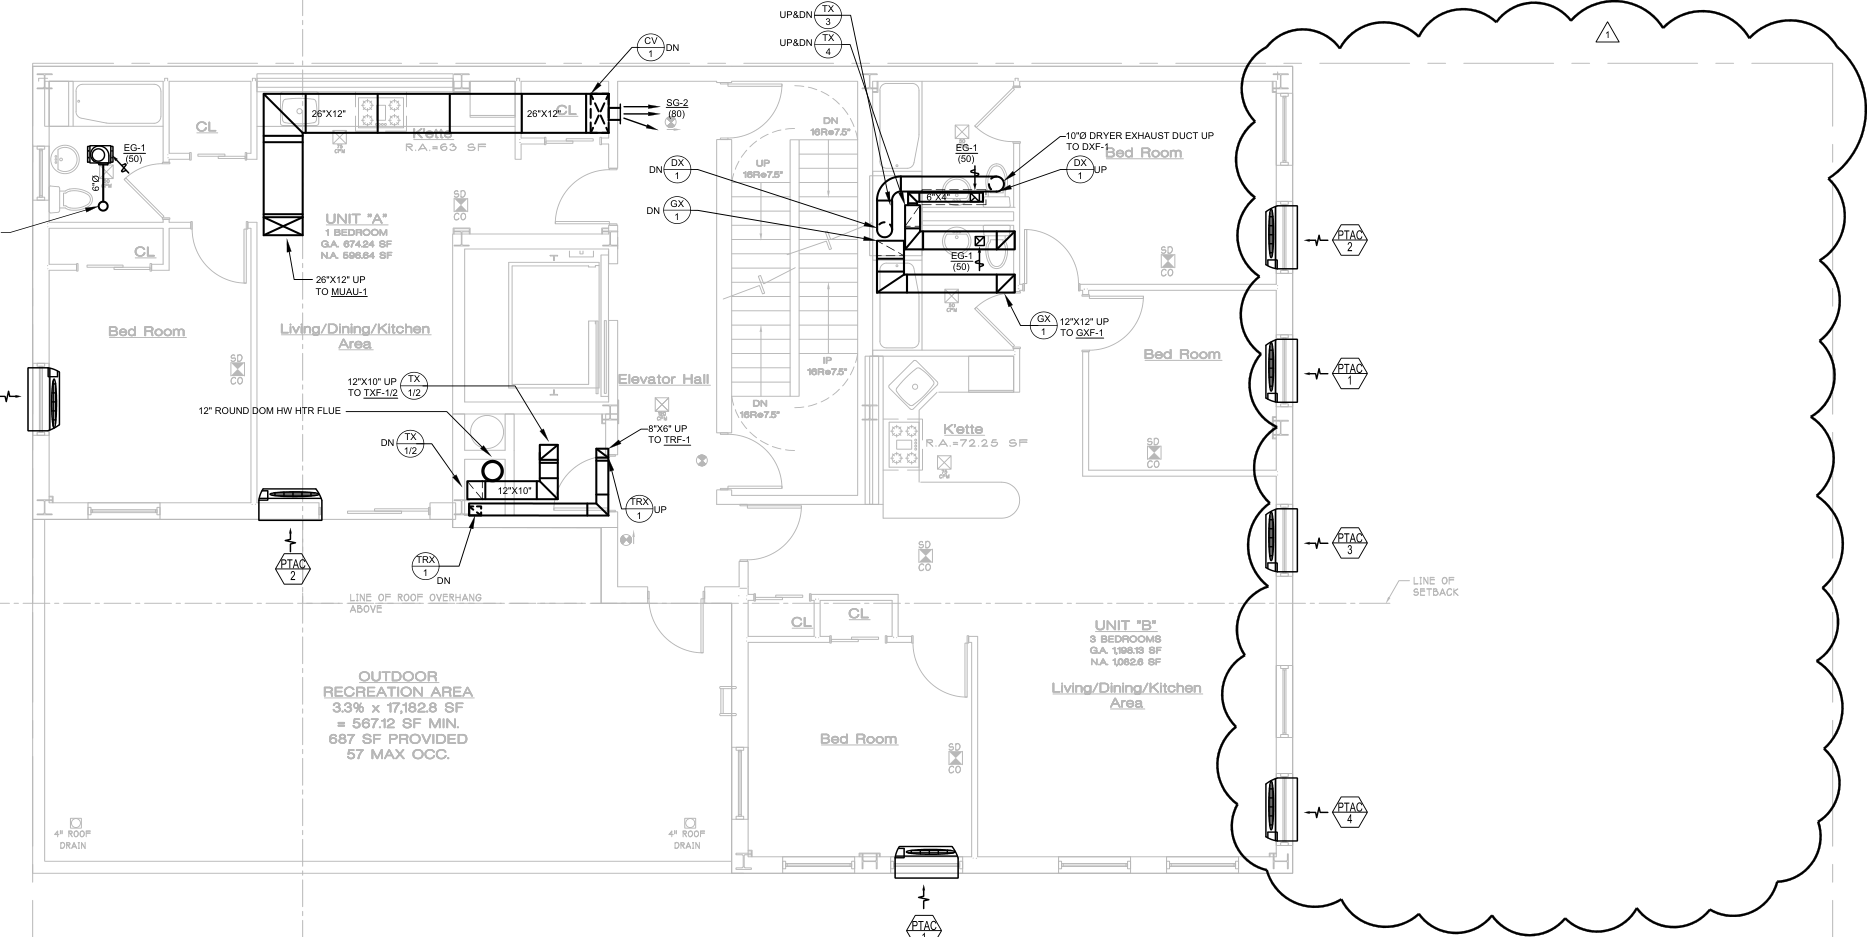

In [69]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_52.png")
mat_file_path = '/content/drive/MyDrive/*Datasets/ground truth data/page_52_labels.mat'

cv2_imshow(img)

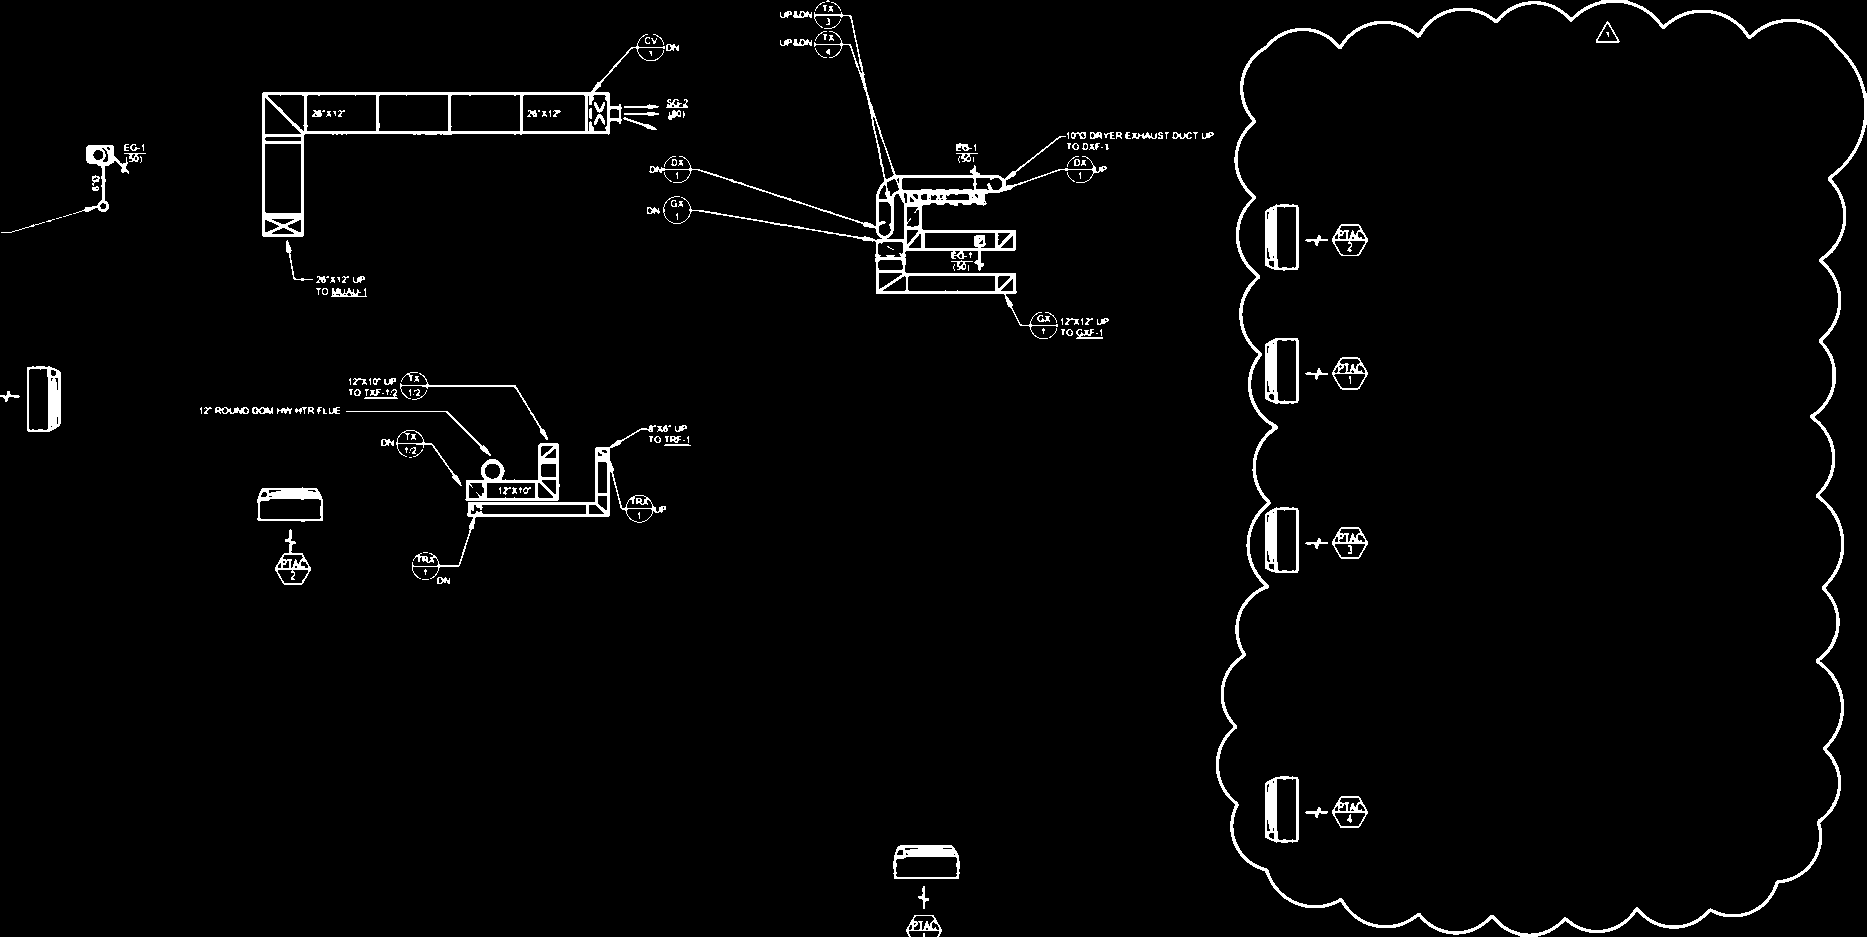

In [70]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

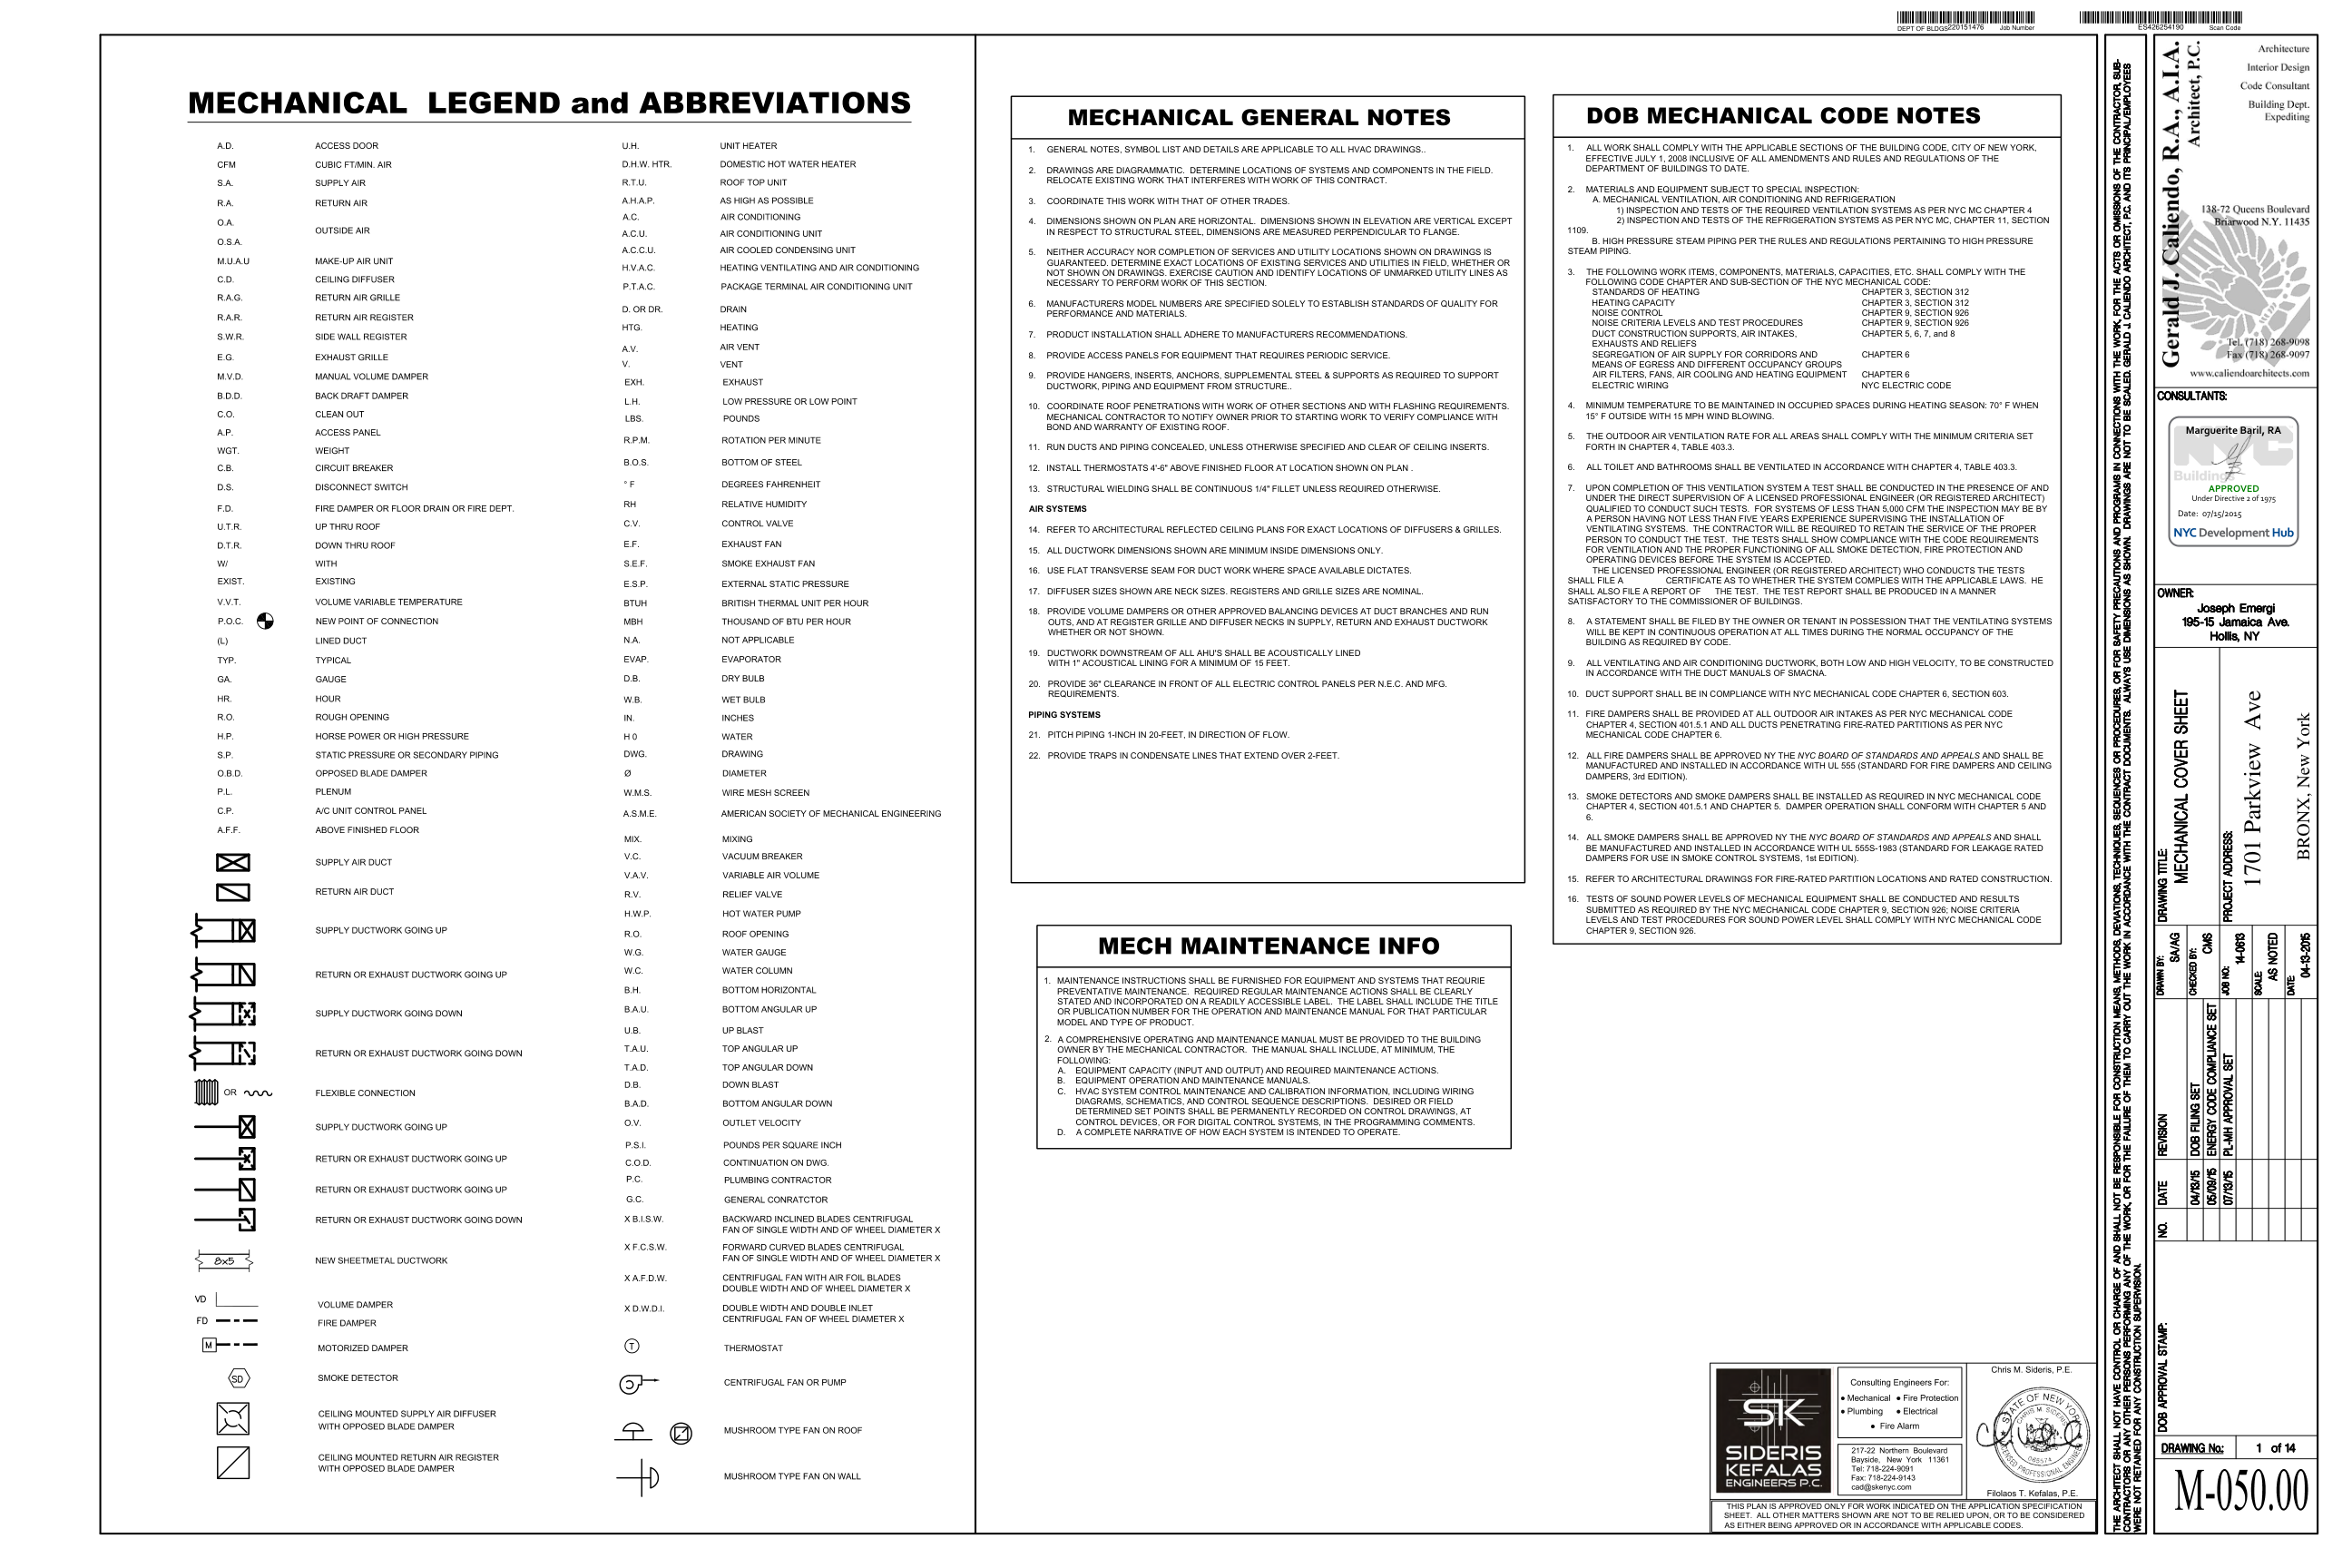

In [71]:
# Load the image using OpenCV
tmp_img = cv2.imread("/content/drive/MyDrive/*Datasets/Parkview Data Images/page_47.png")

cv2_imshow(tmp_img)

Return Duct:


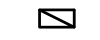

Supply Duct:


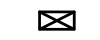

Supply Ductwork Up:


Supply Ductwork Up 2:


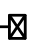

Return Ductwork Up:


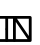

Return Ductwork Up 2:


Return Ductwork Up 3:


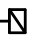

Supply Ductwork Down:


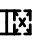

Return Ductwork Down:


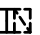

Return Ductwork Down 2:


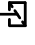

Motorized Damper:


Smoke Detector:


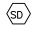

Ceiling Mounted Diffuser:


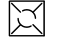

Ceiling Mounted Register:


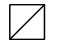

Thermostat:


In [72]:
# Define crop coordinates for the supply and return ducts (adjust these as needed)
# Format: img[y1:y2, x1:x2]
# Example coordinates - these need to be adjusted based on the actual location in the image
supply_duct_crop = tmp_img[930:970, 200:300]
return_duct_crop = tmp_img[965:1005, 200:300]

supply_ductwork_up_crop = tmp_img[1010:1040, 250:290]
supply_ductwork_up_crop_2 = tmp_img[1215:1260, 255:290]

return_ductwork_up_crop = tmp_img[1045:1090, 250:290]
return_ductwork_up_crop_2 = tmp_img[1260:1290, 255:290]
return_ductwork_up_crop_3 = tmp_img[1290:1325, 255:290]

supply_ductwork_down_crop = tmp_img[1095:1135, 250:290]

return_ductwork_down_crop = tmp_img[1140:1175, 250:290]
return_ductwork_down_crop_2 = tmp_img[1330:1375, 255:290]

motorized_damper_crop = tmp_img[1470:1500, 220:245]

smoke_detector_crop = tmp_img[1505:1545, 245:290]
ceiling_mounted_diffuser_crop = tmp_img[1545:1590, 230:290]
ceiling_mounted_register_crop = tmp_img[1590:1630, 230:290]

thermostat_crop = tmp_img[1455:1515, 685:710]

# Display cropped images
print("Return Duct:")
cv2_imshow(return_duct_crop)

print("Supply Duct:")
cv2_imshow(supply_duct_crop)

# Display cropped images
print("Supply Ductwork Up:")
cv2_imshow(supply_ductwork_up_crop)

print("Supply Ductwork Up 2:")
cv2_imshow(supply_ductwork_up_crop_2)

print("Return Ductwork Up:")
cv2_imshow(return_ductwork_up_crop)

print("Return Ductwork Up 2:")
cv2_imshow(return_ductwork_up_crop_2)

print("Return Ductwork Up 3:")
cv2_imshow(return_ductwork_up_crop_3)

# Display cropped images
print("Supply Ductwork Down:")
cv2_imshow(supply_ductwork_down_crop)

print("Return Ductwork Down:")
cv2_imshow(return_ductwork_down_crop)

print("Return Ductwork Down 2:")
cv2_imshow(return_ductwork_down_crop_2)

print("Motorized Damper:")
cv2_imshow(motorized_damper_crop)

# Display cropped images
print("Smoke Detector:")
cv2_imshow(smoke_detector_crop)

print("Ceiling Mounted Diffuser:")
cv2_imshow(ceiling_mounted_diffuser_crop)

print("Ceiling Mounted Register:")
cv2_imshow(ceiling_mounted_register_crop)

print("Thermostat:")
cv2_imshow(thermostat_crop)

In [73]:
# Preprocess Templates
def preprocess_template(template_img):

    gray = cv2.GaussianBlur(template_img, (3, 3), 0)

    # Step 2: Threshold to binary (invert foreground/background)
    _, binary_img = cv2.threshold(template_img, 180, 255, cv2.THRESH_BINARY_INV)

    # Step 3: Apply morphological operations
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=3)
    refined = cv2.dilate(eroded, kernel, iterations=3)

    # Step 4: Crop to content
    coords = cv2.findNonZero(refined)  # Find non-zero pixels
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)  # Get bounding box around content
        cropped = refined[y:y+h, x:x+w]  # Crop the image
    else:
        cropped = refined  # If no non-zero pixels, return the refined image

    return cropped


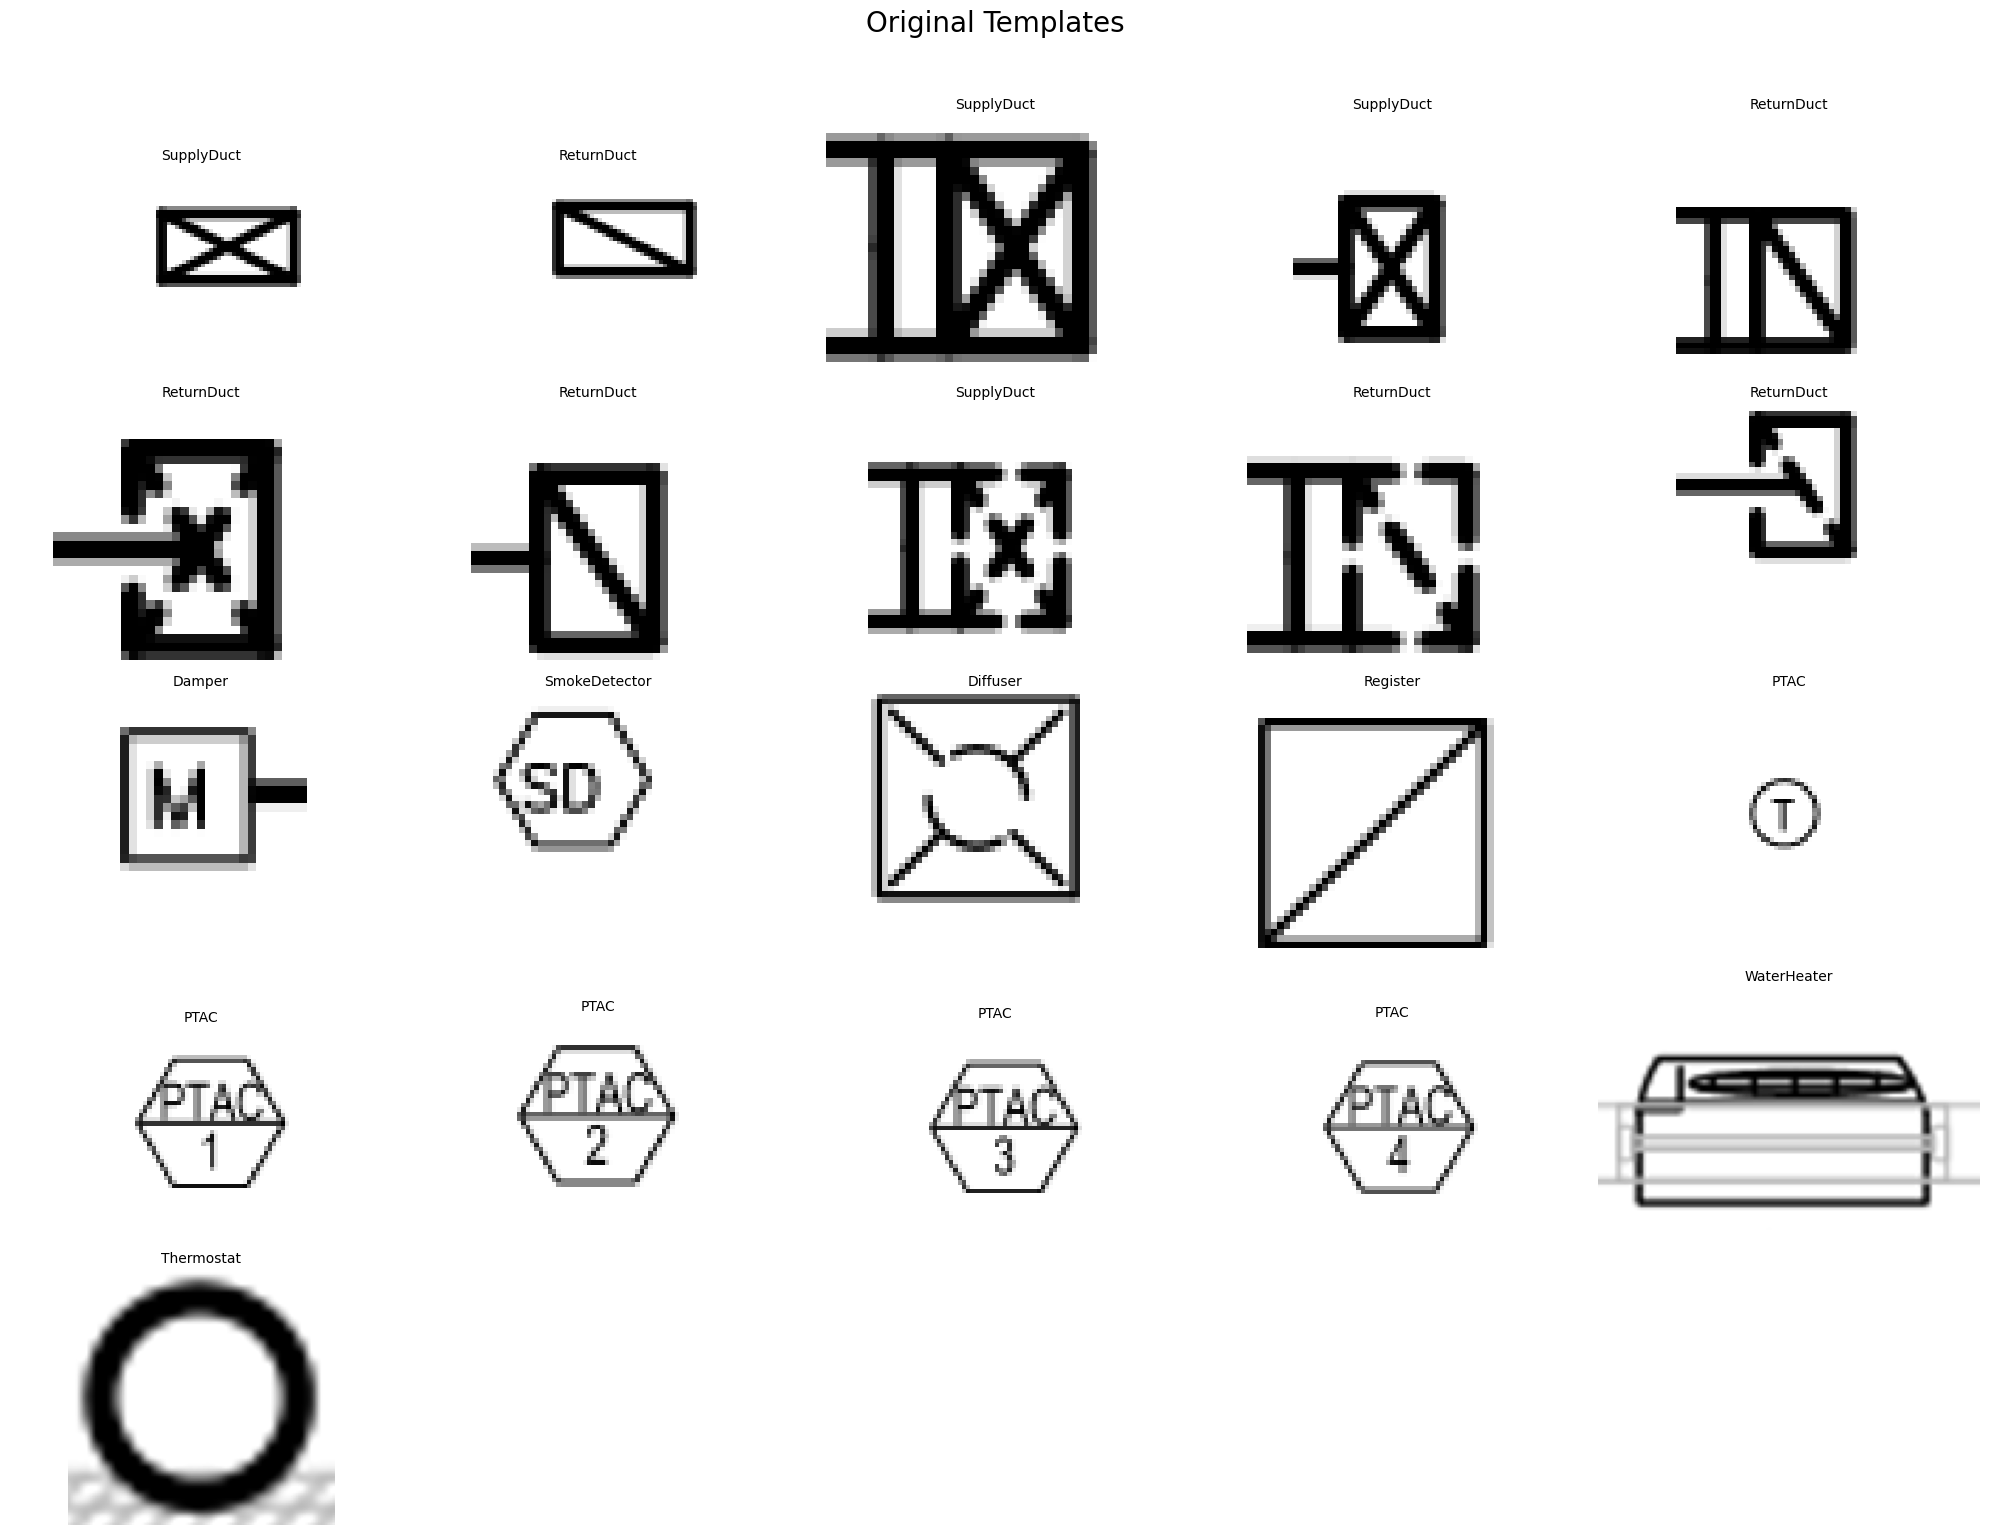

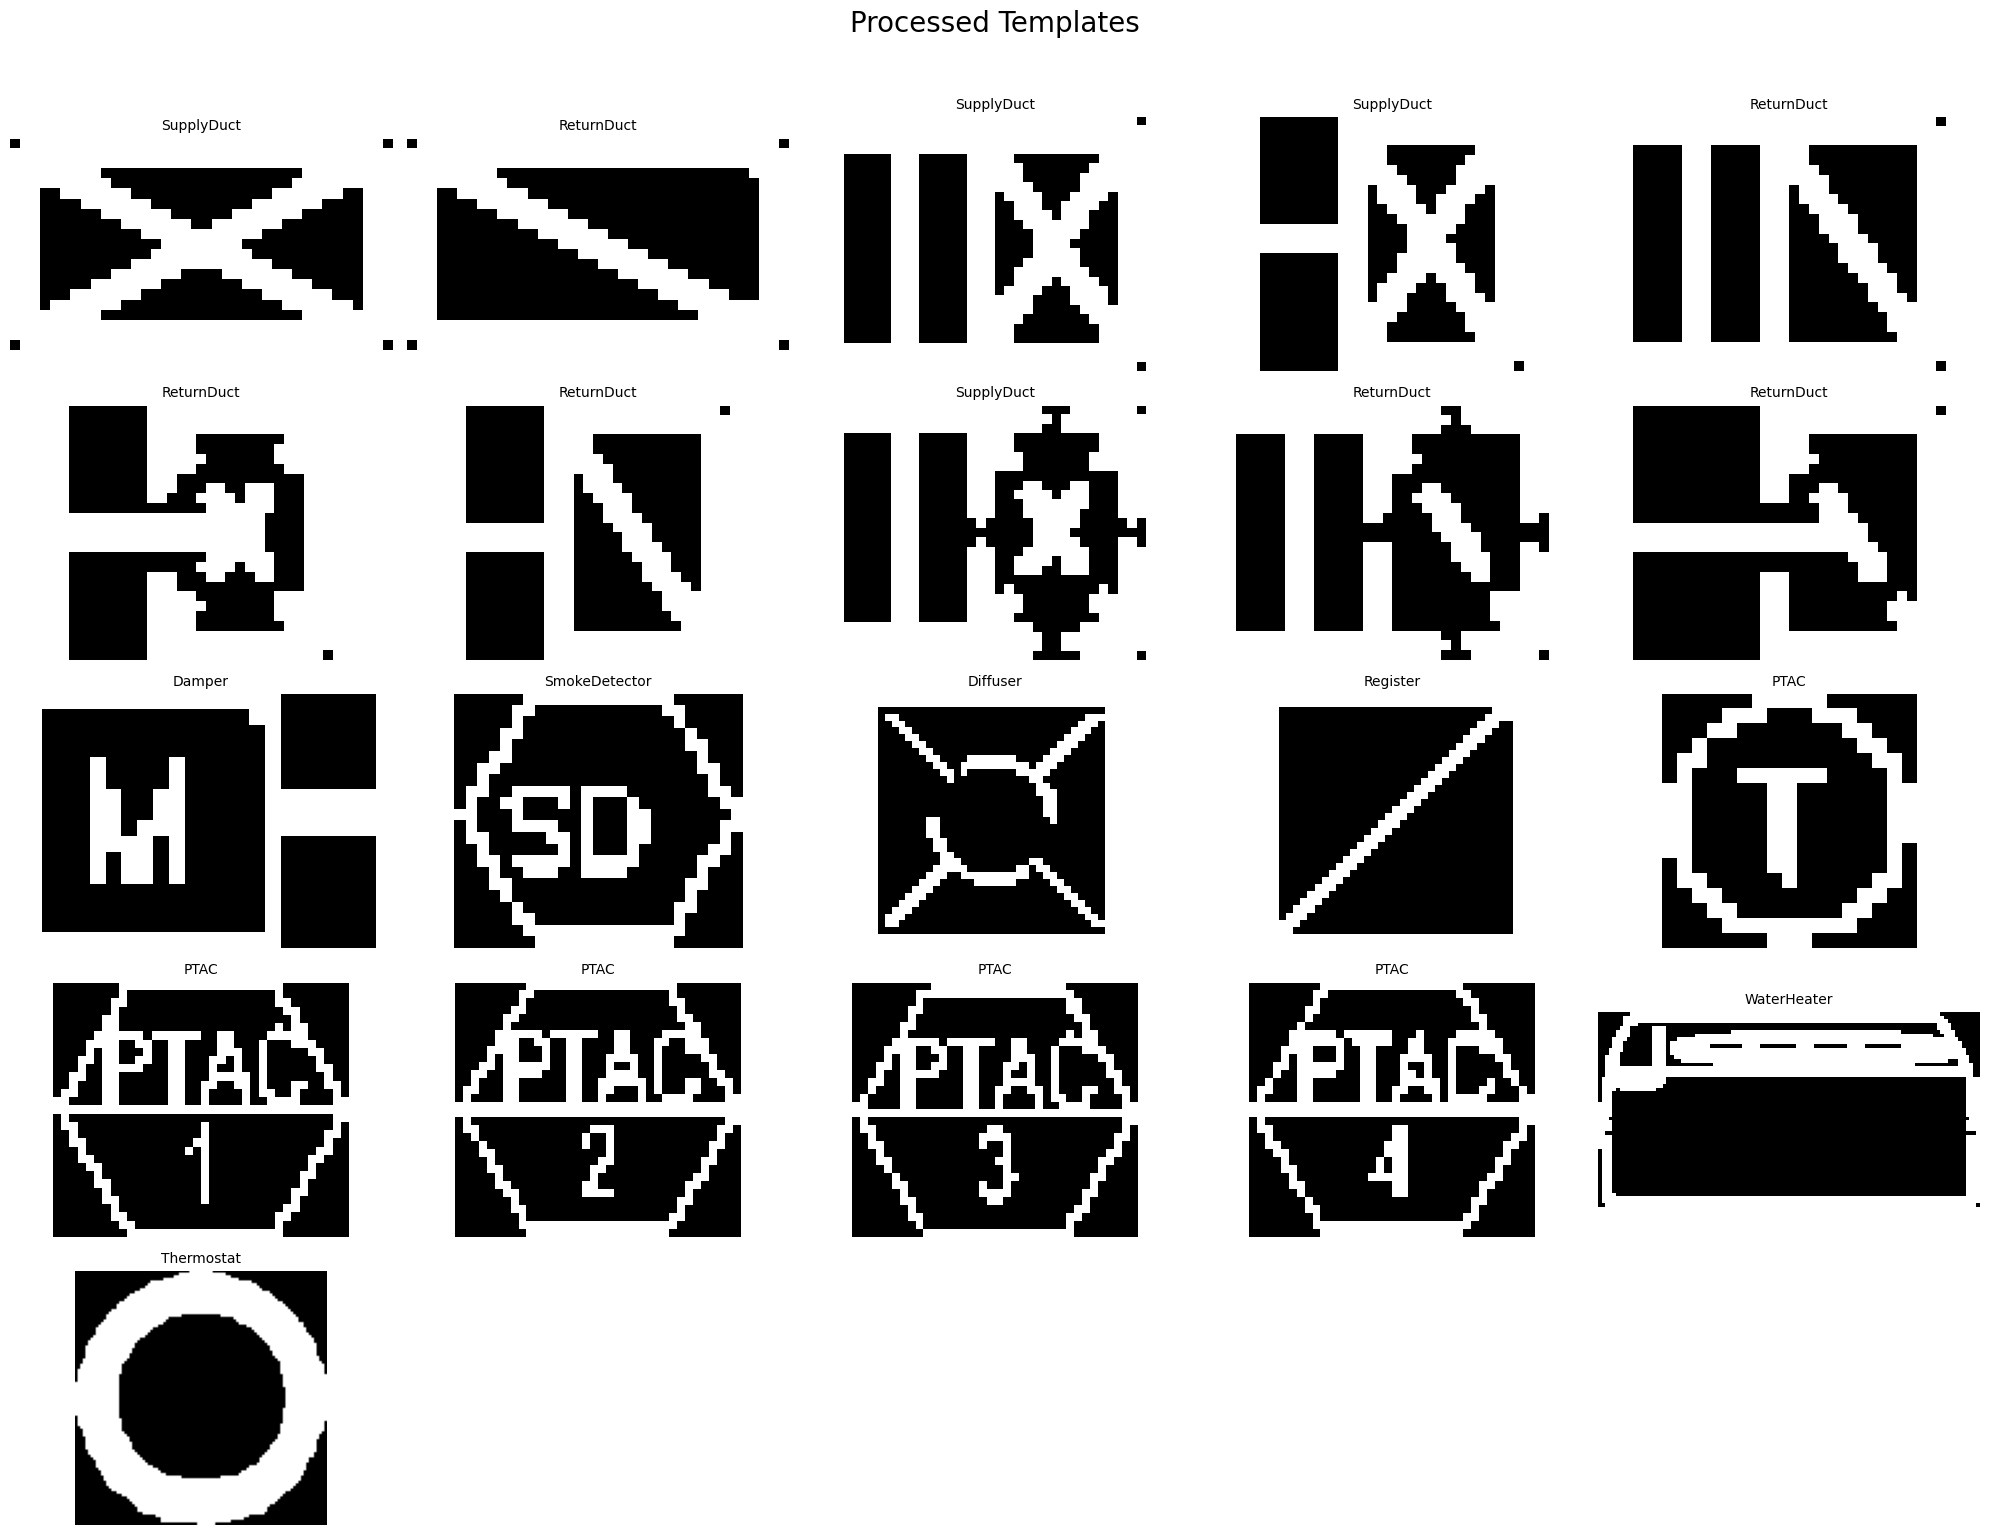

In [74]:
# Define crop coordinates for additional templates with variations
supply_duct_crop = tmp_img[930:970, 200:300]
return_duct_crop = tmp_img[965:1005, 200:300]
supply_ductwork_up_crop = tmp_img[1010:1040, 250:290]
supply_ductwork_up_crop_2 = tmp_img[1215:1260, 255:290]
return_ductwork_up_crop = tmp_img[1045:1090, 250:290]
return_ductwork_up_crop_2 = tmp_img[1260:1290, 255:290]
return_ductwork_up_crop_3 = tmp_img[1290:1325, 255:290]
supply_ductwork_down_crop = tmp_img[1095:1135, 250:290]
return_ductwork_down_crop = tmp_img[1140:1175, 250:290]
return_ductwork_down_crop_2 = tmp_img[1330:1375, 250:290]
motorized_damper_crop = tmp_img[1470:1500, 220:245]
smoke_detector_crop = tmp_img[1505:1545, 245:290]
ceiling_mounted_diffuser_crop = tmp_img[1545:1590, 230:290]
ceiling_mounted_register_crop = tmp_img[1590:1630, 230:290]
thermostat_crop = tmp_img[1455:1515, 685:710]

# Convert cropped templates to grayscale
cropped_templates = [
    cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    for crop in [
        supply_duct_crop,
        return_duct_crop,
        supply_ductwork_up_crop,
        supply_ductwork_up_crop_2,
        return_ductwork_up_crop,
        return_ductwork_up_crop_2,
        return_ductwork_up_crop_3,
        supply_ductwork_down_crop,
        return_ductwork_down_crop,
        return_ductwork_down_crop_2,
        motorized_damper_crop,
        smoke_detector_crop,
        ceiling_mounted_diffuser_crop,
        ceiling_mounted_register_crop,
        thermostat_crop
    ]
]

# Define additional template paths
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

# Define names for all templates, including variations
template_names = [
    'SupplyDuct',
    'ReturnDuct',
    'SupplyDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'ReturnDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'Damper',
    'SmokeDetector',
    'Diffuser',
    'Register',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'WaterHeater',
    'Thermostat'
]

# Load additional templates from the file paths
additional_templates = [cv2.imread(path, 0) for path in template_paths]

# Combine all templates
original_templates = cropped_templates + additional_templates

# Process all templates
processed_templates = [preprocess_template(template) for template in original_templates]

# Parameters for visualization
images_per_row = 5  # Max images per row
n_templates = len(template_names)

# Calculate rows for each plot
n_rows_original = (n_templates + images_per_row - 1) // images_per_row
n_rows_processed = (n_templates + images_per_row - 1) // images_per_row

# Visualization for original templates
plt.figure(figsize=(20, n_rows_original * 3))
plt.suptitle("Original Templates", fontsize=20, y=1.02)

for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:
        row = i // images_per_row
        col = i % images_per_row
        plt.subplot(n_rows_original, images_per_row, row * images_per_row + col + 1)
        plt.imshow(template, cmap='gray')
        plt.title(name, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

# Visualization for processed templates
plt.figure(figsize=(20, n_rows_processed * 3))
plt.suptitle("Processed Templates", fontsize=20, y=1.02)

for i, (template, name) in enumerate(zip(processed_templates, template_names)):
    if template is not None:
        row = i // images_per_row
        col = i % images_per_row
        plt.subplot(n_rows_processed, images_per_row, row * images_per_row + col + 1)
        plt.imshow(template, cmap='gray')
        plt.title(name, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

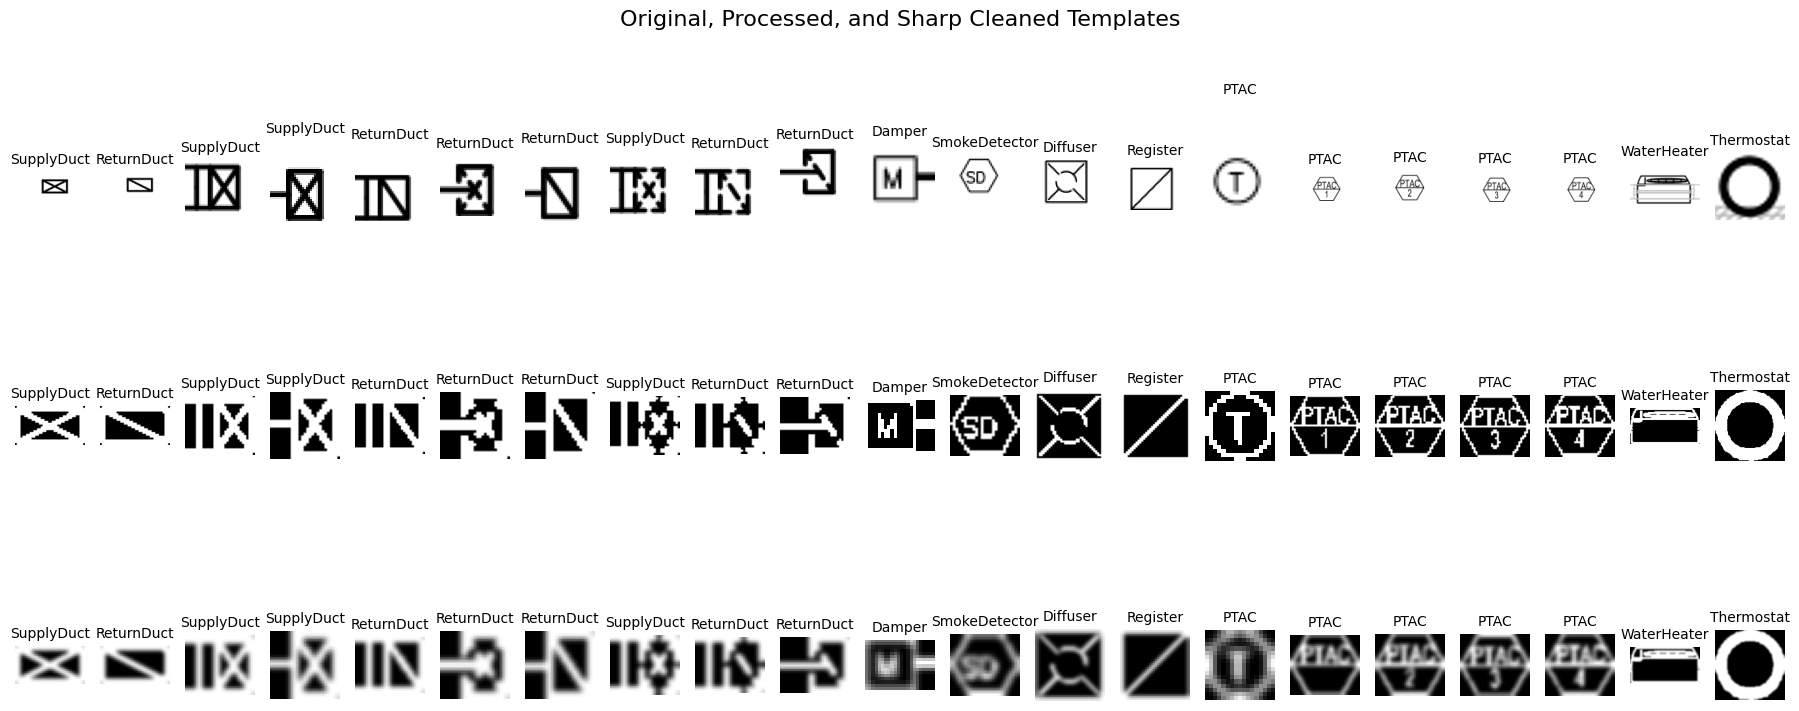

In [75]:
# Define a refined function to clean up noise while retaining sharpness
def refined_clean_template(template, kernel_size=(3, 3), min_area=10, blur_kernel=(2, 2)):
    """
    Cleans up noise in the template with minimal dilation and sharpens the edges.
    :param template: Input binary template (numpy array)
    :param kernel_size: Size of the kernel for morphological operations
    :param min_area: Minimum area to retain connected components
    :param blur_kernel: Kernel size for Gaussian blur to smooth edges
    :return: Cleaned and sharpened template
    """
    # Create a kernel for morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)

    # Perform morphological closing to fill small gaps
    cleaned_template = cv2.morphologyEx(template, cv2.MORPH_CLOSE, kernel)

    # Remove small connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned_template)
    for i in range(1, num_labels):  # Start from 1 to skip the background
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            cleaned_template[labels == i] = 0  # Remove small components

    # Apply GaussianBlur to smooth edges slightly
    if blur_kernel != (0, 0):
        cleaned_template = cv2.GaussianBlur(cleaned_template, blur_kernel, 0)

    return cleaned_template

# Clean up processed templates with refined settings
sharp_cleaned_templates = [
    refined_clean_template(template, kernel_size=(1, 1), min_area=15, blur_kernel=(5, 5))
    for template in processed_templates
]

# Visualize the refined cleaned templates
plt.figure(figsize=(18, 8))  # Adjust the size for better display

# Display original templates (Row 1)
for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

# Display processed templates (Row 2)
for i, (template, name) in enumerate(zip(processed_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, n_templates + i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

# Display sharp cleaned templates (Row 3)
for i, (template, name) in enumerate(zip(sharp_cleaned_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, 2 * n_templates + i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.suptitle("Original, Processed, and Sharp Cleaned Templates", fontsize=16, y=1.02)
plt.show()


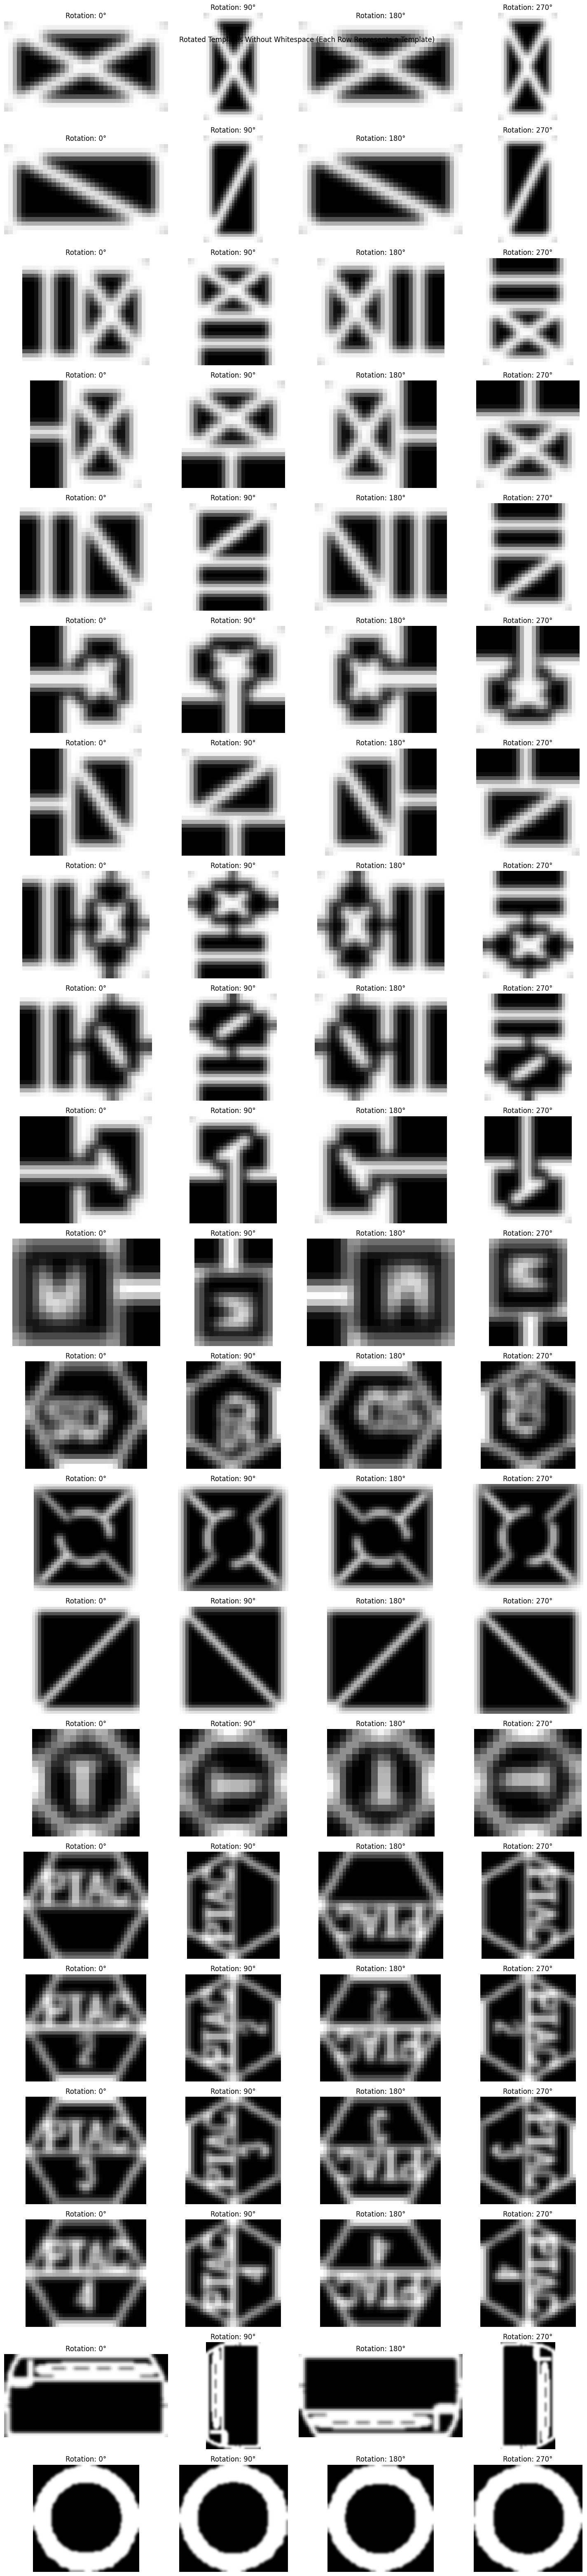

In [76]:
# Function to crop the non-zero region of the image
def crop_to_nonzero(image):
    # Find all non-zero coordinates
    coords = cv2.findNonZero(image)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped_image = image[y:y + h, x:x + w]
        return cropped_image
    return image  # Return the original image if no non-zero region is found

# Define a function to preprocess templates and extract contours at specific 90-degree angles
def template_rotations(template_img, rotation_angles=[0, 90, 180, 270]):
    rotated_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        # Compute the diagonal length to create a larger canvas
        diagonal = int(np.sqrt(h**2 + w**2))
        canvas_size = (diagonal, diagonal)
        center = (diagonal // 2, diagonal // 2)

        # Pad the template to fit the new canvas size
        padded_template = cv2.copyMakeBorder(template_img,
                                             top=(diagonal - h) // 2,
                                             bottom=(diagonal - h) // 2,
                                             left=(diagonal - w) // 2,
                                             right=(diagonal - w) // 2,
                                             borderType=cv2.BORDER_CONSTANT,
                                             value=0)

        # Compute the rotation matrix
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        # Rotate the padded template
        rotated_template = cv2.warpAffine(padded_template, M, canvas_size)

        # Crop to remove the whitespace
        cropped_template = crop_to_nonzero(rotated_template)

        # Store the cropped template
        rotated_templates.append(cropped_template)
    return rotated_templates

# Preprocess and store rotated templates
all_template_variants = []
for template in sharp_cleaned_templates:
    if template is not None:
        rotated_templates = template_rotations(template, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)

# Visualize rotated templates without whitespace
fig, axes = plt.subplots(len(all_template_variants), 4, figsize=(15, len(all_template_variants) * 3))
fig.suptitle("Rotated Templates Without Whitespace (Each Row Represents a Template)")

for row_idx, rotated_templates in enumerate(all_template_variants):
    for col_idx, rotated_template in enumerate(rotated_templates):
        ax = axes[row_idx, col_idx]
        ax.imshow(rotated_template, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Rotation: {col_idx * 90}°")

plt.tight_layout()
plt.show()

Invariant-Template-Matching: https://github.com/cozheyuanzhangde/Invariant-TemplateMatching

In [77]:
# IoU Calculation Function
def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)  # Avoid division by zero
    return iou

def non_max_suppression_with_scores(boxes, scores, iou_threshold=0.5):
    """
    Perform Non-Maximum Suppression (NMS) on bounding boxes with scores.

    Args:
        boxes (list or ndarray): List/Array of bounding boxes in (x1, y1, x2, y2) format.
        scores (list or ndarray): Corresponding confidence scores for the bounding boxes.
        iou_threshold (float): IoU threshold to suppress overlapping boxes.

    Returns:
        selected_boxes (ndarray): Array of selected bounding boxes.
        selected_scores (ndarray): Array of corresponding scores for selected boxes.
    """
    if len(boxes) == 0:
        return [], []

    # Convert to numpy arrays
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)

    # Sort boxes by scores in descending order
    sorted_indices = np.argsort(scores)[::-1]

    selected_boxes = []
    selected_scores = []

    while len(sorted_indices) > 0:
        # Select the highest-scoring box
        current_index = sorted_indices[0]
        selected_boxes.append(boxes[current_index])
        selected_scores.append(scores[current_index])

        # Compute IoUs with remaining boxes
        current_box = boxes[current_index]
        remaining_boxes = boxes[sorted_indices[1:]]
        ious = np.array([calculate_iou(current_box, box) for box in remaining_boxes])

        # Keep indices of boxes with IoU <= threshold
        sorted_indices = sorted_indices[np.where(ious <= iou_threshold)[0] + 1]

    # Convert to numpy arrays and return
    return np.array(selected_boxes, dtype=np.int32), np.array(selected_scores, dtype=np.float32)

def remove_intersections(boxes, scores=None, iou_threshold=0.5):
    """Remove intersecting bounding boxes using IoU threshold."""
    if scores is None:
        scores = [1] * len(boxes)

    non_intersecting_boxes = []
    non_intersecting_scores = []

    for i, current_box in enumerate(boxes):
        keep = True
        for j, other_box in enumerate(non_intersecting_boxes):
            if calculate_iou(current_box, other_box) > iou_threshold:
                if scores[i] > non_intersecting_scores[j]:
                    # Replace the suppressed box with the current higher-score box
                    non_intersecting_boxes[j] = current_box
                    non_intersecting_scores[j] = scores[i]
                keep = False
                break

        if keep:
            non_intersecting_boxes.append(current_box)
            non_intersecting_scores.append(scores[i])

    return non_intersecting_boxes, non_intersecting_scores

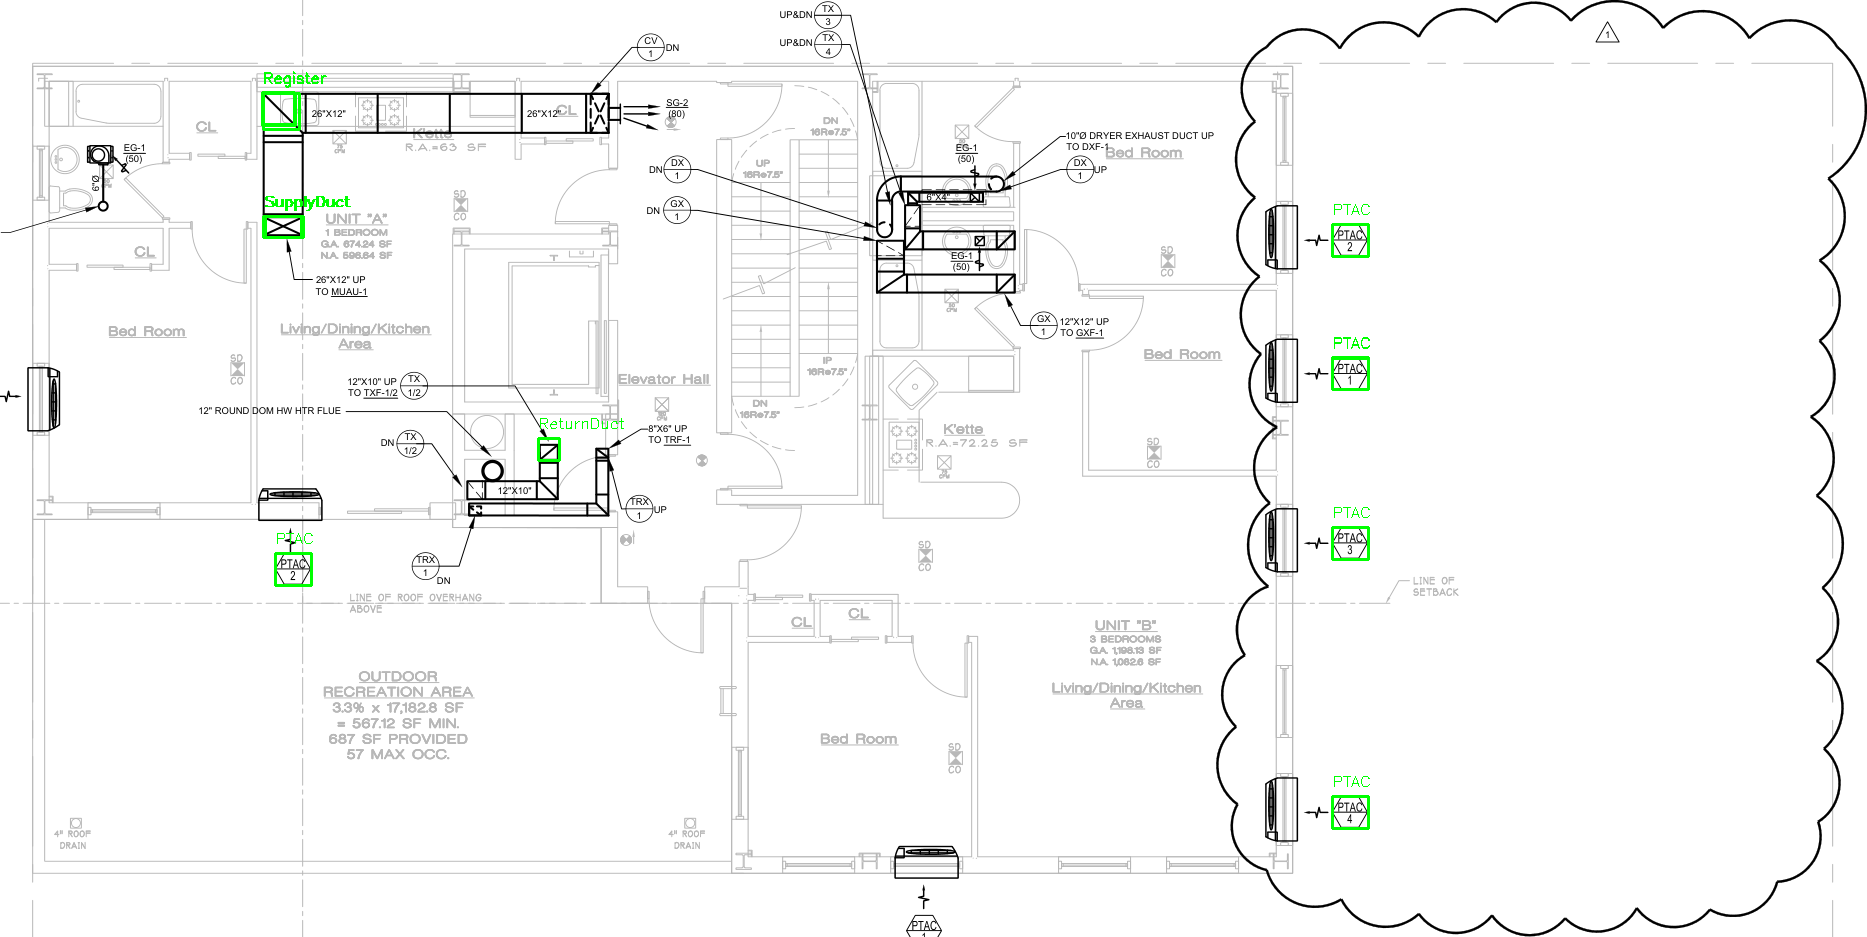

In [79]:
# Define the scales and threshold for template matching
scales = [1.0, 0.9, 0.8, 0.7]
threshold = 0.75
iou_threshold = 0.5

# Define colors for each unique template
template_colors = {
    "SupplyDuct": (255, 0, 0),  # Red
    "ReturnDuct": (0, 255, 0),  # Green
    "PTAC": (0, 0, 255),  # Blue
    "WaterHeater": (255, 255, 0),  # Yellow
    "Thermostat": (255, 0, 255),  # Magenta
    "Damper": (0, 255, 255),  # Cyan
    "Diffuser": (255, 165, 0),  # Orange
    "Register": (128, 0, 128),  # Purple
    "SmokeDetector": (128, 128, 0)  # Olive
}

# Initialize the dictionary to store predicted bounding boxes
predicted_boxes = {
    "SupplyDuct": [],
    "ReturnDuct": [],
    "PTAC": [],
    "WaterHeater": [],
    "Thermostat": [],
    "Damper": [],
    "Diffuser": [],
    "Register": [],
    "SmokeDetector": []
}


# Initialize storage for unique template matches and scores
unique_template_matches = defaultdict(list)
template_scores = defaultdict(list)

# Debugging: Track total matches and skipped matches
total_matches = 0
total_skipped_matches = 0

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    for scaled_template in template_variants:  # Each item in template_variants is a rotated template
        for scale in scales:
            # Resize the scaled template
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Perform template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                score = result[y, x]  # Confidence score

                # Ensure the bounding box matches the scaled template
                bbox_start_x = int(x)
                bbox_start_y = int(y)
                bbox_end_x = int(x + w)
                bbox_end_y = int(y + h)

                # Check if bounding box fits within the image
                if bbox_end_x <= dilated.shape[1] and bbox_end_y <= dilated.shape[0]:
                    # Store matches and scores
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(score)
                    total_matches += 1
                else:
                    total_skipped_matches += 1

# Create a copy of the image to draw matches
image_with_matches = img.copy()

# Loop through each template type and its matches
for template_name, boxes in unique_template_matches.items():
    color = template_colors.get(template_name.lower(), (0, 255, 0))  # Default to green if undefined
    for (startX, startY, endX, endY) in boxes:
        width, height = endX - startX, endY - startY
        # Ensure valid coordinates
        if startX >= 0 and startY >= 0 and endX <= image_with_matches.shape[1] and endY <= image_with_matches.shape[0]:
            cv2.rectangle(image_with_matches, (startX, startY), (endX, endY), color, 2)
            cv2.putText(image_with_matches, template_name, (startX, startY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the image with all matches
cv2_imshow(image_with_matches)



[DEBUG] Filtered Matches After NMS (Formatted):
PTAC bounding boxes: [[275, 553, 36, 32], [1332, 796, 36, 32], [1332, 527, 36, 32], [1332, 224, 36, 32], [1332, 357, 36, 32]]
Register bounding boxes: [[263, 93, 32, 32]]
SupplyDuct bounding boxes: [[264, 216, 38, 21]]
ReturnDuct bounding boxes: [[538, 438, 21, 22]]


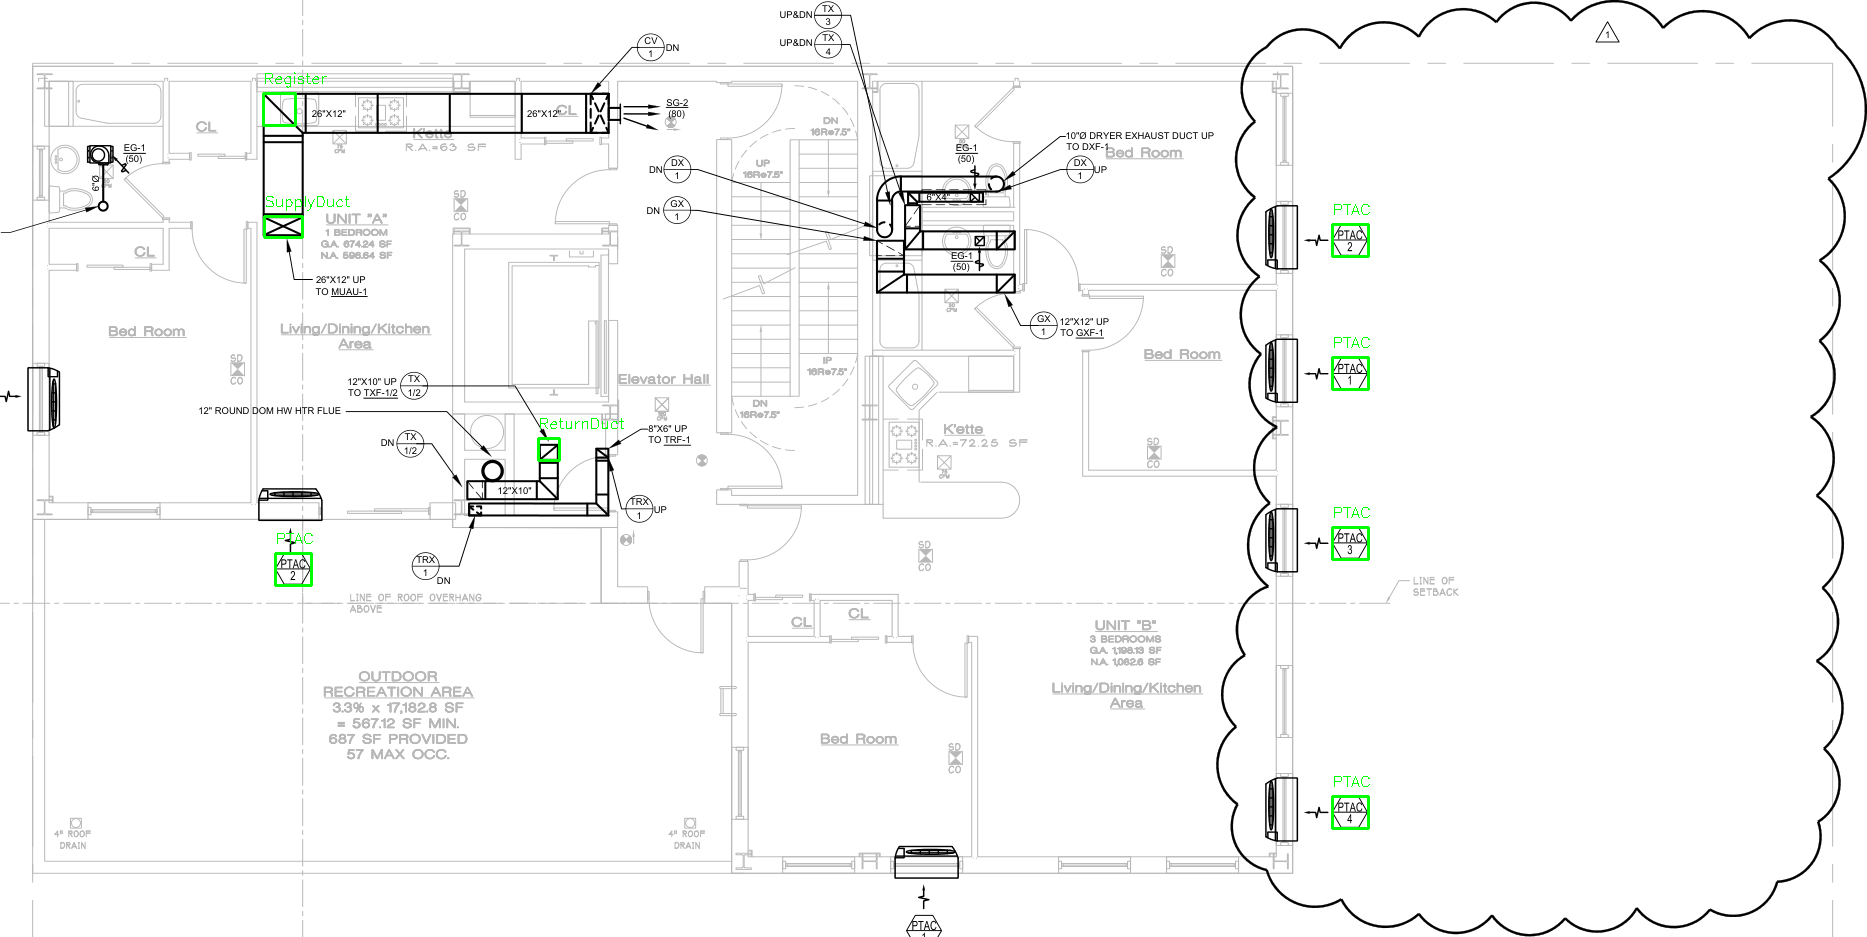

In [80]:
# Perform NMS-like filtering across all templates
filtered_boxes = []
filtered_template_names = []

# Flatten all boxes and their corresponding template names into a single list
all_boxes = []
all_scores = []
all_template_names = []

for template_name, boxes in unique_template_matches.items():
    for i, box in enumerate(boxes):
        all_boxes.append(box)
        all_scores.append(template_scores[template_name][i])
        all_template_names.append(template_name)

# Convert to numpy arrays with proper formatting
all_boxes = np.array(all_boxes, dtype=np.float32)  # Ensure numeric format
all_scores = np.array(all_scores, dtype=np.float32)
all_template_names = np.array(all_template_names)

# Sort boxes by their scores in descending order
sorted_indices = np.argsort(all_scores)[::-1]
all_boxes = all_boxes[sorted_indices]
all_template_names = all_template_names[sorted_indices]

# Perform Non-Maximum Suppression
while len(all_boxes) > 0:
    # Pick the box with the highest score
    selected_box = all_boxes[0]
    selected_template_name = all_template_names[0]
    filtered_boxes.append(selected_box)
    filtered_template_names.append(selected_template_name)

    # Compute IoU for the selected box with all remaining boxes
    ious = np.array([calculate_iou(selected_box, other_box) for other_box in all_boxes[1:]])

    # Remove boxes with IoU above the threshold
    remaining_indices = np.where(ious <= iou_threshold)[0] + 1  # Offset by 1 due to slicing
    all_boxes = all_boxes[remaining_indices]
    all_template_names = all_template_names[remaining_indices]

# Group filtered matches by template type
filtered_matches_grouped = defaultdict(list)
for template_name, box in zip(filtered_template_names, filtered_boxes):
    # Convert to (x, y, w, h) format
    x, y, x2, y2 = map(int, box)
    filtered_matches_grouped[template_name].append([x, y, x2 - x, y2 - y])

# Print filtered matches in the required format
print("\n[DEBUG] Filtered Matches After NMS (Formatted):")
for template_name, boxes in filtered_matches_grouped.items():
    print(f"{template_name} bounding boxes: {boxes}")

# Visualizing the filtered matches
filtered_image = img.copy()

for template_name, (startX, startY, endX, endY) in zip(filtered_template_names, filtered_boxes):
    color = template_colors.get(template_name.lower(), (0, 255, 0))
    # Convert coordinates to integers
    startX, startY, endX, endY = int(startX), int(startY), int(endX), int(endY)
    cv2.rectangle(filtered_image, (startX, startY), (endX, endY), color, 2)
    cv2.putText(filtered_image, template_name, (startX, startY - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the filtered image
cv2_imshow(filtered_image)


Evaluate object detection using ground-truth-labeled image from MATLAB image labeler.

In [81]:
# Load the .mat file
mat_data = loadmat(mat_file_path)

# Inspect the keys to identify the structure
print("Keys in the .mat file:", mat_data.keys())

# Extract the struct
labels_struct = mat_data['labelsStruct']  # Adjust based on the key name

# Parse bounding boxes for each label type
def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats


# Parse ground truth bounding boxes
parsed_labels = []
for row in labels_struct:
    # Safely extract elements, defaulting to None if row[0] is None or incomplete
    if row[0] is not None:
        unpacked = list(row[0]) + [None] * (9 - len(row[0]))  # Ensure all 9 elements
    else:
        unpacked = [None] * 9

    # Assign to corresponding labels
    supply_duct, return_duct, ptac, water_heater, thermostat, damper, diffuser, register, smoke_detector = unpacked

    # Append parsed labels for each type
    parsed_labels.append({
        "SupplyDuct": parse_bounding_boxes(supply_duct) if supply_duct is not None else [],
        "ReturnDuct": parse_bounding_boxes(return_duct) if return_duct is not None else [],
        "PTAC": parse_bounding_boxes(ptac) if ptac is not None else [],
        "WaterHeater": parse_bounding_boxes(water_heater) if water_heater is not None else [],
        "Thermostat": parse_bounding_boxes(thermostat) if thermostat is not None else [],
        "Damper": parse_bounding_boxes(damper) if damper is not None else [],
        "Diffuser": parse_bounding_boxes(diffuser) if diffuser is not None else [],
        "Register": parse_bounding_boxes(register) if register is not None else [],
        "SmokeDetector": parse_bounding_boxes(smoke_detector) if smoke_detector is not None else []
    })

# Assign the first row's parsed labels to `ground_truth_boxes`
ground_truth_boxes = parsed_labels[0]
supply_duct_boxes = ground_truth_boxes["SupplyDuct"]
return_duct_boxes = ground_truth_boxes["ReturnDuct"]
ptac_boxes = ground_truth_boxes["PTAC"]
water_heater_boxes = ground_truth_boxes["WaterHeater"]
thermostat_boxes = ground_truth_boxes["Thermostat"]
damper_boxes = ground_truth_boxes["Damper"]
diffuser_boxes = ground_truth_boxes["Diffuser"]
register_boxes = ground_truth_boxes["Register"]
smoke_detector_boxes = ground_truth_boxes["SmokeDetector"]

# Display parsed bounding boxes
print("\n[DEBUG] Ground Truth Bounding Boxes:")
print("SupplyDuct bounding boxes:", supply_duct_boxes)
print("ReturnDuct bounding boxes:", return_duct_boxes)
print("PTAC bounding boxes:", ptac_boxes)
print("WaterHeater bounding boxes:", water_heater_boxes)
print("Thermostat bounding boxes:", thermostat_boxes)
print("Damper bounding boxes:", damper_boxes)
print("Diffuser bounding boxes:", diffuser_boxes)
print("Register bounding boxes:", register_boxes)
print("SmokeDetector bounding boxes:", smoke_detector_boxes)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'labelsStruct'])

[DEBUG] Ground Truth Bounding Boxes:
SupplyDuct bounding boxes: [[260, 214, 49, 27], [587, 90, 26, 48]]
ReturnDuct bounding boxes: [[996, 227, 23, 28], [994, 271, 25, 27], [536, 442, 27, 21], [594, 447, 18, 15], [468, 503, 16, 16], [466, 478, 23, 23], [874, 238, 35, 25], [903, 204, 21, 27]]
PTAC bounding boxes: [[24, 365, 43, 68], [252, 487, 81, 41], [276, 552, 38, 35], [889, 839, 76, 44], [1332, 795, 41, 36], [1260, 776, 45, 68], [1332, 528, 38, 35], [1263, 509, 41, 68], [1331, 355, 40, 38], [1264, 338, 40, 70], [1264, 206, 39, 67], [1331, 222, 39, 38]]
WaterHeater bounding boxes: [[480, 460, 27, 23]]
Thermostat bounding boxes: []
Damper bounding boxes: []
Diffuser bounding boxes: []
Register bounding boxes: []
SmokeDetector bounding boxes: []


In [82]:
# Function to calculate IoU
def calculate_iou(gt_box, pred_box):
    """Calculate IoU between two bounding boxes."""
    from shapely.geometry import box  # Local import to ensure `box` is correct

    # Convert ground truth and prediction boxes to Shapely box objects
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])  # Convert (x, y, w, h) to (x1, y1, x2, y2)
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])

    # Calculate intersection and union areas
    intersection = gt.intersection(pred).area
    union = gt.union(pred).area

    # Return IoU
    return intersection / union if union > 0 else 0


# Function to match predictions to ground truth
def match_predictions(gt_boxes, pred_boxes, iou_threshold):
    matches = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                matches.append((gt, pred, iou))
    return matches

# Function to calculate precision and recall for a single label type
def calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    return precision, recall

# Function to calculate total metrics
def calculate_total_metrics(gt_boxes, pred_boxes, iou_threshold):
    total_true_matches = 0
    total_ground_truth = sum(len(gt) for gt in gt_boxes.values())
    total_predictions = sum(len(pred) for pred in pred_boxes.values())
    tp, fp, fn = 0, 0, 0
    mismatches = 0

    for gt, pred in zip(gt_boxes.values(), pred_boxes.values()):
        matched_gt = set()
        for pred_box in pred:
            matched = False
            for i, gt_box in enumerate(gt):
                if calculate_iou(gt_box, pred_box) >= iou_threshold and i not in matched_gt:
                    tp += 1
                    matched_gt.add(i)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn += len(gt) - len(matched_gt)
    mismatches = fp
    return total_true_matches, total_ground_truth, total_predictions, tp, fp, fn, mismatches

# Function to calculate mean Average Precision (mAP)
def calculate_map(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    ap = (precision + recall) / 2 if precision > 0 or recall > 0 else 0
    return ap

# Draw bounding boxes
def draw_boxes(image, boxes, color, label):
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Annotate IoU
def annotate_iou(image, gt_boxes, pred_boxes, color, iou_threshold):
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                cv2.putText(
                    image, f"IoU: {iou:.2f}", (pred[0], pred[1] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
                )


[DEBUG] Predicted Boxes After NMS:
SupplyDuct: [[264, 216, 38, 21]]
ReturnDuct: [[538, 438, 21, 22]]
PTAC: [[275, 553, 36, 32], [1332, 796, 36, 32], [1332, 224, 36, 32]]
WaterHeater: []
Thermostat: []
Damper: []
Diffuser: []
Register: [[263, 93, 32, 32]]
SmokeDetector: []

[DEBUG] Predicted Boxes Before Visualization:
SupplyDuct: [[264, 216, 38, 21]]
ReturnDuct: [[538, 438, 21, 22]]
PTAC: [[275, 553, 36, 32], [1332, 796, 36, 32], [1332, 224, 36, 32]]
WaterHeater: []
Thermostat: []
Damper: []
Diffuser: []
Register: [[263, 93, 32, 32]]
SmokeDetector: []


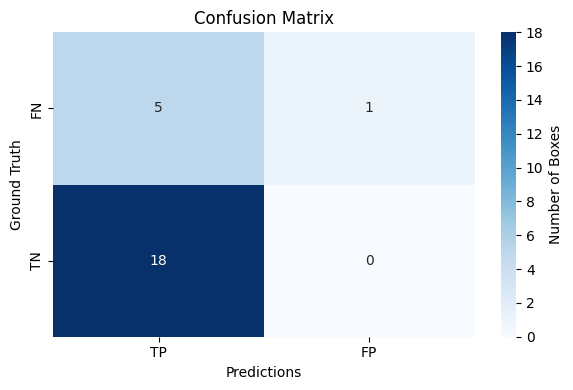

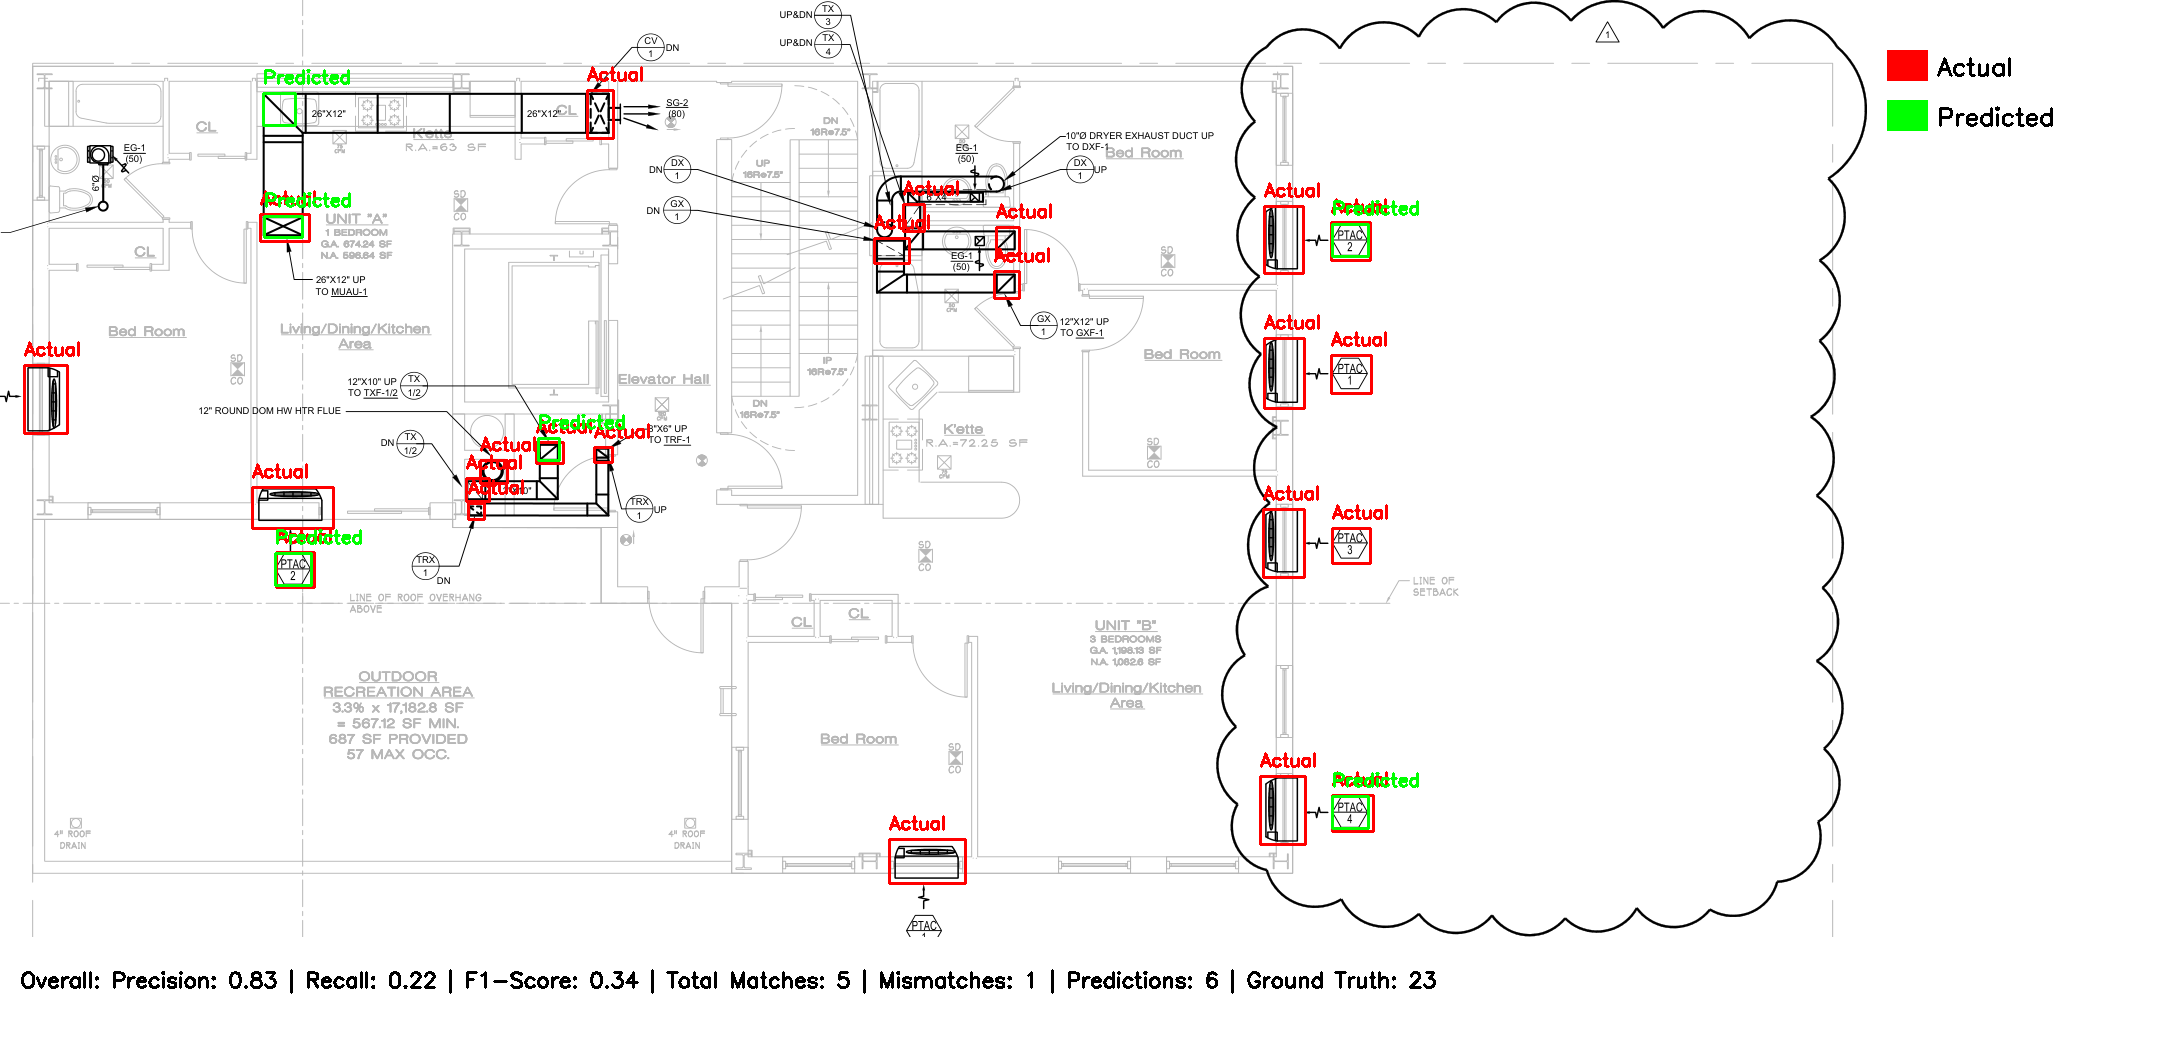

In [83]:
# Perform NMS-like filtering across all templates
filtered_boxes = []
filtered_template_names = []
iou_threshold = 0.2  # Set IoU threshold for filtering

# Flatten all boxes and their corresponding template names into a single list
all_boxes = []
all_scores = []
all_template_names = []

for template_name, boxes in unique_template_matches.items():
    for i, box in enumerate(boxes):
        all_boxes.append(box)
        all_scores.append(template_scores[template_name][i])
        all_template_names.append(template_name)

# Convert to numpy arrays with proper formatting
all_boxes = np.array(all_boxes, dtype=np.float32)  # Ensure numeric format
all_scores = np.array(all_scores, dtype=np.float32)
all_template_names = np.array(all_template_names)

# Sort boxes by their scores in descending order
sorted_indices = np.argsort(all_scores)[::-1]
all_boxes = all_boxes[sorted_indices]
all_template_names = all_template_names[sorted_indices]

# Perform Non-Maximum Suppression
while len(all_boxes) > 0:
    # Pick the box with the highest score
    selected_box = all_boxes[0]
    selected_template_name = all_template_names[0]
    filtered_boxes.append(selected_box)
    filtered_template_names.append(selected_template_name)

    # Compute IoU for the selected box with all remaining boxes
    ious = np.array([calculate_iou(selected_box, other_box) for other_box in all_boxes[1:]])

    # Remove boxes with IoU above the threshold
    remaining_indices = np.where(ious <= iou_threshold)[0] + 1  # Offset by 1 due to slicing
    all_boxes = all_boxes[remaining_indices]
    all_template_names = all_template_names[remaining_indices]

# Ensure filtered_boxes are normalized to (x, y, w, h)
filtered_boxes_normalized = [
    [box[0], box[1], box[2] - box[0], box[3] - box[1]] for box in filtered_boxes
]

# Prepare predicted_boxes for each template type
predicted_boxes = {
    label: [] for label in [
        "SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater",
        "Thermostat", "Damper", "Diffuser", "Register", "SmokeDetector"
    ]
}

for template_name, box in zip(filtered_template_names, filtered_boxes_normalized):
    predicted_boxes[template_name].append([int(coord) for coord in box])

# Debugging: Display predicted boxes after NMS
print("\n[DEBUG] Predicted Boxes After NMS:")
for label, boxes in predicted_boxes.items():
    print(f"{label}: {boxes}")

# Debugging: Save the predicted boxes for comparison
predicted_boxes_debug = predicted_boxes.copy()

# Visualization and Metrics
# Debugging: Verify transfer of predicted_boxes
print("\n[DEBUG] Predicted Boxes Before Visualization:")
for label, boxes in predicted_boxes_debug.items():
    print(f"{label}: {boxes}")

# Draw bounding boxes and calculate metrics
visualized_image = img.copy()  # Replace `img` with your input image
colors = {
    "Actual": (0, 0, 255),  # Red for ground truth
    "Predicted": (0, 255, 0),  # Green for predicted boxes
}

# Include all unique template names in the loop
for label_type in [
    "SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater",
    "Thermostat", "Damper", "Diffuser", "Register", "SmokeDetector"
]:
    gt_boxes = ground_truth_boxes.get(label_type, [])  # Ground truth boxes
    pred_boxes = predicted_boxes.get(label_type, [])  # Predicted boxes

    # Draw ground truth (red)
    draw_boxes(visualized_image, gt_boxes, colors["Actual"], "Actual")

    # Draw predictions (green)
    draw_boxes(visualized_image, pred_boxes, colors["Predicted"], "Predicted")

# Calculate and annotate metrics
total_true_matches, total_ground_truth, total_predictions, tp, fp, fn, mismatches = calculate_total_metrics(
    ground_truth_boxes, predicted_boxes, iou_threshold
)

# Generate confusion matrix
conf_matrix = np.array([[tp, mismatches], [fn, total_ground_truth - tp - fn]])
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=["TP", "FP"], yticklabels=["FN", "TN"],
    cbar_kws={'label': 'Number of Boxes'}
)
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

# Draw legend and metrics summary
legend_width = 300
bottom_padding = 100
canvas = np.ones((visualized_image.shape[0] + bottom_padding, visualized_image.shape[1] + legend_width, 3), dtype=np.uint8) * 255
canvas[:visualized_image.shape[0], :visualized_image.shape[1]] = visualized_image

legend_y_start = 50
legend_y_step = 50
for idx, (label, color) in enumerate(colors.items()):
    y_pos = legend_y_start + idx * legend_y_step
    cv2.rectangle(canvas, (visualized_image.shape[1] + 20, y_pos), (visualized_image.shape[1] + 60, y_pos + 30), color, -1)
    cv2.putText(canvas, label, (visualized_image.shape[1] + 70, y_pos + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

summary_label = (
    f"Overall: Precision: {precision:.2f} | Recall: {recall:.2f} | "
    f"F1-Score: {f1_score:.2f} | Total Matches: {tp} | Mismatches: {mismatches} | "
    f"Predictions: {total_predictions} | Ground Truth: {total_ground_truth}"
)
cv2.putText(canvas, summary_label, (20, canvas.shape[0] - 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

cv2_imshow(canvas)

## Matching Threshold Evaluation

In [38]:
# Define threshold values to evaluate
threshold_values = np.arange(0.1, 0.96, 0.1)  # Adjust thresholds from 0.4 to 0.95

# Initialize precision and recall storage
precision_results = defaultdict(list)
recall_results = defaultdict(list)

# IoU threshold for a "true match"
iou_threshold = 0.2

# Loop over threshold values and evaluate the matching algorithm
for threshold in threshold_values:
    print(f"Evaluating for Threshold: {threshold:.2f}")

    # Initialize storage for template matches and scores
    unique_template_matches = defaultdict(list)
    template_scores = defaultdict(list)

    # Loop through each set of template variants
    for template_variants, template_name in zip(all_template_variants, template_names):
        for scaled_template in template_variants:
            for scale in scales:
                # Resize the scaled template
                scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
                (h, w) = scaled_template_resized.shape[:2]

                # Perform template matching
                result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
                (yCoords, xCoords) = np.where(result >= threshold)

                for (x, y) in zip(xCoords, yCoords):
                    score = result[y, x]  # Confidence score

                    # Ensure the bounding box matches the scaled template
                    bbox_start_x = int(x)
                    bbox_start_y = int(y)
                    bbox_end_x = int(x + w)
                    bbox_end_y = int(y + h)

                    # Store matches and scores
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(score)

    # Combine matches across scales and rotations
    combined_template_matches = defaultdict(list)
    combined_template_scores = defaultdict(list)

    for template_name in unique_template_matches.keys():
        combined_template_matches[template_name].extend(unique_template_matches[template_name])
        combined_template_scores[template_name].extend(template_scores[template_name])

    # Initialize predicted_boxes for each template type
    predicted_boxes = {label: [] for label in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater",
    "Thermostat", "Damper", "Diffuser", "Register", "SmokeDetector"]}

    # Apply NMS for each template type
    for template_name, boxes in combined_template_matches.items():
        if not boxes:
            continue

        # Convert bounding boxes and scores to numpy arrays
        boxes_np = np.array(boxes)
        scores_np = np.array(combined_template_scores[template_name])

        # Apply NMS
        filtered_boxes = non_max_suppression_with_scores(boxes_np, scores_np, iou_threshold=0.2)

        # Store filtered bounding boxes for the fixed template names
        for (startX, startY, endX, endY) in filtered_boxes:
            width, height = endX - startX, endY - startY
            predicted_boxes[template_name].append([startX, startY, width, height])

    # Evaluate precision and recall for each label type
    for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
        gt_boxes = ground_truth_boxes[label_type]
        pred_boxes = predicted_boxes[label_type]

        # Calculate precision and recall
        true_matches = sum(
            any(calculate_iou(gt, pred) >= iou_threshold for pred in pred_boxes)
            for gt in gt_boxes
        )
        precision = true_matches / len(pred_boxes) if len(pred_boxes) > 0 else 0
        recall = true_matches / len(gt_boxes) if len(gt_boxes) > 0 else 0

        # Store results
        precision_results[label_type].append(precision)
        recall_results[label_type].append(recall)

        # Debugging output for intermediate results
        print(f"Label: {label_type}, Threshold: {threshold:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}")

# Plot Precision and Recall for each label type
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
    plt.figure(figsize=(10, 6))
    plt.plot(threshold_values, precision_results[label_type], label=f"{label_type} Precision", linestyle="--")
    plt.plot(threshold_values, recall_results[label_type], label=f"{label_type} Recall", linestyle="-")
    plt.xlabel("Threshold Values", fontsize=12)
    plt.ylabel("Performance Metrics", fontsize=12)
    plt.title(f"Precision and Recall for {label_type} Across Threshold Values", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()


Evaluating for Threshold: 0.10


KeyboardInterrupt: 

## IoU Threshold Distribtions vs Precision/Recall

*Which IoU threshold value to choose?*

In [39]:
# Function to compute Precision, Recall, and F1-Score
def compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives

    matched_gt = set()

    for pred_box in predicted_boxes:
        match_found = False
        for i, gt_box in enumerate(ground_truth_boxes):
            if i in matched_gt:  # Skip already matched ground truth boxes
                continue
            iou = calculate_iou(gt_box, pred_box)
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1

    fn = len(ground_truth_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Function to compute IoU distribution
def compute_iou_distribution(predicted_boxes, ground_truth_boxes):
    iou_values = []
    for pred_box in predicted_boxes:
        best_iou = 0
        for gt_box in ground_truth_boxes:
            iou = calculate_iou(gt_box, pred_box)
            best_iou = max(best_iou, iou)
        iou_values.append(best_iou)
    return iou_values

# Function for parameter sensitivity analysis (Precision, Recall, F1-Score)
def parameter_sensitivity_analysis(predicted_boxes, ground_truth_boxes, iou_thresholds):
    precisions = []
    recalls = []
    f1_scores = []

    for threshold in iou_thresholds:
        precision, recall, f1 = compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold=threshold)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return precisions, recalls, f1_scores

# Function to plot metrics per template with proper labels
def plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds):
    num_templates = len(template_names)
    fig, axes = plt.subplots(num_templates, 2, figsize=(18, 6 * num_templates))

    for idx, template_name in enumerate(template_names):
        pred_boxes = predicted_boxes[template_name]
        gt_boxes = ground_truth_boxes[template_name]

        # Compute IoU distribution
        iou_distribution = compute_iou_distribution(pred_boxes, gt_boxes)

        # Plot IoU distribution
        axes[idx, 0].hist(iou_distribution, bins=10, range=(0, 1), color="skyblue", edgecolor="black")
        axes[idx, 0].set_title(f"{template_name} IoU Distribution", fontsize=14)
        axes[idx, 0].set_xlabel("IoU", fontsize=12)
        axes[idx, 0].set_ylabel("Frequency", fontsize=12)
        axes[idx, 0].grid(True, linestyle="--", alpha=0.6)

        # Perform sensitivity analysis
        precisions, recalls, f1_scores = parameter_sensitivity_analysis(pred_boxes, gt_boxes, iou_thresholds)

        # Plot Precision, Recall, and F1-Score vs IoU threshold
        axes[idx, 1].plot(iou_thresholds, precisions, label="Precision", marker="o", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, recalls, label="Recall", marker="s", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, f1_scores, label="F1-Score", marker="^", linestyle="--")
        axes[idx, 1].set_title(f"{template_name} Metrics vs IoU Threshold", fontsize=14)
        axes[idx, 1].set_xlabel("IoU Threshold", fontsize=12)
        axes[idx, 1].set_ylabel("Metric Value", fontsize=12)
        axes[idx, 1].legend(loc="lower left", fontsize=10)
        axes[idx, 1].grid(True, linestyle="--", alpha=0.6)
        axes[idx, 1].set_xticks(iou_thresholds)
        axes[idx, 1].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

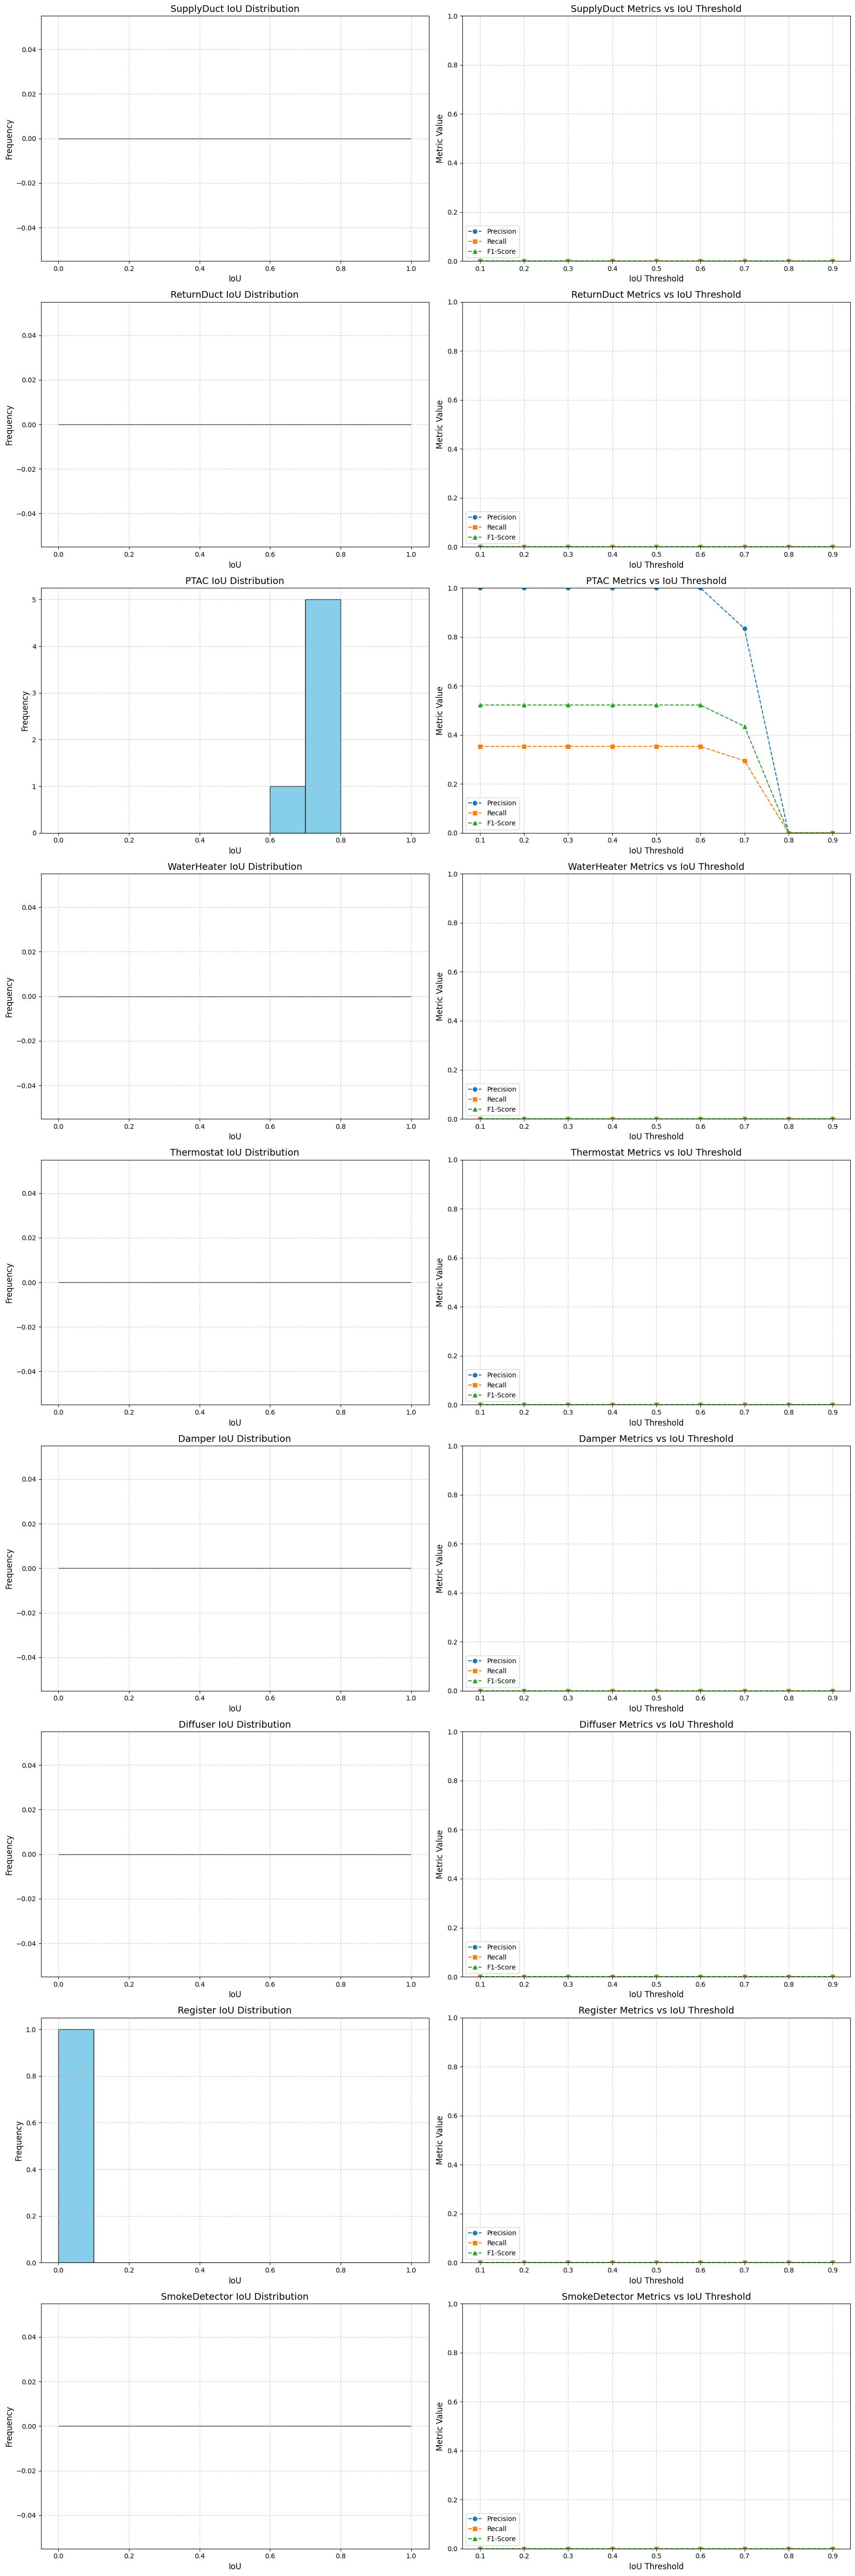

In [40]:
# Template names and IoU thresholds for analysis
template_names = ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater",
    "Thermostat", "Damper", "Diffuser", "Register", "SmokeDetector"]
iou_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot metrics for each template type
plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds)


The IoU distribution plots show how well the predicted bounding boxes align with the ground truth for each template type:
- For SupplyDuct, predictions align well with a strong peak around IoU ~0.8, indicating good overlap.
- ReturnDuct has no meaningful IoU values, reflecting a complete failure in generating accurate predictions.
- For PTAC, the IoU values are distributed more broadly, with most predictions falling between 0.2 and 0.6, showing some moderate alignment but also significant inconsistency in precision.

The Performance Metrics vs. IoU Threshold plots evaluate precision, recall, and F1-Score at varying IoU thresholds.
- SupplyDuct maintains good metrics at lower thresholds (0.1–0.5) but drops significantly at stricter thresholds due to less precise alignment.
- ReturnDuct consistently scores near zero across all thresholds, further confirming poor prediction performance.
- PTAC shows moderate performance at lower thresholds, but all metrics decline sharply as thresholds increase, highlighting its struggle with precise localization.


These results suggest strong detection for SupplyDuct, limited success for PTAC, and a need for significant improvement in ReturnDuct predictions.

In [ ]:
# Import required libraries
import cv2
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.io import loadmat
from shapely.geometry import box
import seaborn as sns

# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

# Template names for prediction
template_names = [
    'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend',
    'water_heater'
]

# Ground truth template names from .mat files
ground_truth_names = [
    'ReturnDuct',
    'SupplyDuct',
    'PTAC',
    'WaterHeater'
]

# Image paths (pages 48 to 52 inclusive)
page_range = range(48, 53)
image_paths = [f"/content/drive/MyDrive/*Datasets/processed_data/page_{page}.png" for page in page_range]
ground_truth_paths = [f"/content/drive/MyDrive/*Datasets/ground truth data/page_{page}_labels.mat" for page in page_range]

# Load templates
original_templates = [cv2.imread(path, 0) for path in template_paths]

# Add flipped version of "Return Air Duct"
if original_templates[0] is not None:
    flipped_return_duct = cv2.flip(original_templates[0], 1)
    original_templates.insert(1, flipped_return_duct)
    template_names.insert(1, 'return_duct_flipped')

# Function: Preprocess templates with rotations
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))
        coords = cv2.findNonZero(rotated_template)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = rotated_template[y:y + h, x:x + w]
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))
    return processed_templates

# Preprocess templates
templates = [preprocess_template_with_all_contours(template) for template in original_templates if template is not None]

# Function: Preprocess input images
def preprocess_image(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=2)
    dilated = cv2.dilate(eroded, kernel, iterations=2)
    return dilated

# Function: Calculate IoU
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)
    return iou

# Function: Non-Maximum Suppression (NMS)
def non_max_suppression(boxes, scores, iou_threshold=0.2):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    sorted_indices = np.argsort(scores)[::-1]
    selected_boxes = []
    while len(sorted_indices) > 0:
        current_index = sorted_indices[0]
        selected_boxes.append(current_index)
        ious = [
            calculate_iou(boxes[current_index], boxes[other_index])
            for other_index in sorted_indices[1:]
        ]
        sorted_indices = np.delete(
            sorted_indices,
            np.where(np.array(ious) > iou_threshold)[0] + 1
        )
        sorted_indices = sorted_indices[1:]
    return boxes[selected_boxes].astype("int")

def format_predicted_bboxes(predicted_boxes, template_names):
    """Format predicted bounding boxes into a structure similar to ground truth."""
    formatted_predictions = {}
    for template_name in template_names:
        if template_name in predicted_boxes:
            formatted_predictions[template_name] = predicted_boxes[template_name]
        else:
            formatted_predictions[template_name] = []  # No predictions for this template
    return formatted_predictions

def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats

# Initialize storage
scales = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]
threshold = 0.7
iou_threshold = 0.2
confusion_matrix = defaultdict(lambda: {"TP": 0, "FP": 0, "FN": 0})

# Iterate through pages
for page_number, (img_path, mat_path) in enumerate(zip(image_paths, ground_truth_paths), start=48):
    print(f"\nProcessing Page {page_number}:")  # Log the current page being processed

    # Load the image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image at {img_path}")
        continue

    # Preprocess the image
    dilated = preprocess_image(img)

    # Load ground truth from .mat file
    mat_data = loadmat(mat_path)
    labels_struct = mat_data.get('labelsStruct', None)
    if labels_struct is None:
        print(f"Error: No labelsStruct found in {mat_path}")
        continue

    # Parse ground truth boxes
    ground_truth_boxes = {}
    for ground_truth_name in ground_truth_names:
        if ground_truth_name in labels_struct.dtype.names:  # Ensure the label exists in the structure
            bboxes = labels_struct[ground_truth_name][0, 0]
            parsed_bboxes = parse_bounding_boxes(bboxes)
            if not parsed_bboxes:
                print(f"No valid bounding boxes found for {ground_truth_name}")
            ground_truth_boxes[ground_truth_name] = parsed_bboxes
        else:
            print(f"Label {ground_truth_name} not found in labelsStruct.")
            ground_truth_boxes[ground_truth_name] = []

    # Print parsed bounding boxes for debugging
    for label, boxes in ground_truth_boxes.items():
        print(f"{label} bounding boxes: {boxes}")

    # Initialize storage for unique template matches and scores
    unique_template_matches = defaultdict(list)
    template_scores = defaultdict(list)

    # Match templates and record bounding boxes
    for template_variants, template_name in zip(templates, template_names):
        for scaled_template, _ in template_variants:
            for scale in scales:
                scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
                h, w = scaled_template_resized.shape[:2]
                result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
                y_coords, x_coords = np.where(result >= threshold)

                # Log matches for debugging
                if len(x_coords) > 0:
                    print(f"Matched Template: {template_name}, Scale: {scale}, Matches: {len(x_coords)}")

                for x, y in zip(x_coords, y_coords):
                    bbox_start_x = int(x)
                    bbox_start_y = int(y)
                    bbox_end_x = int(x + w)
                    bbox_end_y = int(y + h)
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(result[y, x])

    # Combine matches across all scales and rotations
    combined_template_matches = defaultdict(list)
    combined_template_scores = defaultdict(list)

    for template_name in unique_template_matches.keys():
        combined_template_matches[template_name].extend(unique_template_matches[template_name])
        combined_template_scores[template_name].extend(template_scores[template_name])

    # Apply Non-Max Suppression (NMS) to refine predictions
    predicted_boxes = {
        "SupplyDuct": [],
        "ReturnDuct": [],
        "PTAC": [],
        "WaterHeater": []
    }

    for template_name, boxes in combined_template_matches.items():
        if not boxes:
            continue

        boxes_np = np.array(boxes)
        scores_np = np.array(combined_template_scores[template_name])

        # Apply NMS
        filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold)

        # Store filtered bounding boxes
        for (start_x, start_y, end_x, end_y) in filtered_boxes:
            width, height = end_x - start_x, end_y - start_y
            if template_name == "supply_duct":
                predicted_boxes["SupplyDuct"].append([start_x, start_y, width, height])
            elif template_name == "return_duct":
                predicted_boxes["ReturnDuct"].append([start_x, start_y, width, height])
            elif template_name == "ptac_legend":
                predicted_boxes["PTAC"].append([start_x, start_y, width, height])
            elif template_name == "water_heater":
                predicted_boxes["WaterHeater"].append([start_x, start_y, width, height])


    # Debugging: Print filtered bounding boxes for verification
    print("Filtered Predicted Bounding Boxes:")
    for label, boxes in predicted_boxes.items():
        print(f"{label}: {boxes}")

    # Format predictions to match ground truth structure
    formatted_predictions = format_predicted_bboxes(predicted_boxes, template_names)

    # Evaluate predictions against ground truth
    for ground_truth_name, template_name in zip(ground_truth_names, template_names):
        gt_boxes = ground_truth_boxes.get(ground_truth_name, [])
        pred_boxes = formatted_predictions.get(template_name.capitalize(), [])
        tp, fp, fn = 0, 0, 0
        matched_gt = set()

        # Check IoU for matches
        for pred in pred_boxes:
            matched = False
            for i, gt in enumerate(gt_boxes):
                if i not in matched_gt and calculate_iou(gt, pred) >= iou_threshold:
                    tp += 1
                    matched_gt.add(i)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn = len(gt_boxes) - len(matched_gt)

        # Update confusion matrix
        confusion_matrix[ground_truth_name]["TP"] += tp
        confusion_matrix[ground_truth_name]["FP"] += fp
        confusion_matrix[ground_truth_name]["FN"] += fn

        # Debugging: Print evaluation results for each template
        print(f"Evaluation for {ground_truth_name}: TP={tp}, FP={fp}, FN={fn}")

# Debug: Print confusion matrix
print("Confusion Matrix:")
for label, metrics in confusion_matrix.items():
    print(f"{label}: TP={metrics['TP']}, FP={metrics['FP']}, FN={metrics['FN']}")

# Calculate total metrics across all pages
total_tp = sum([cm["TP"] for cm in confusion_matrix.values()])
total_fp = sum([cm["FP"] for cm in confusion_matrix.values()])
total_fn = sum([cm["FN"] for cm in confusion_matrix.values()])

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Generate confusion matrix plot
conf_matrix = np.array([[total_tp, total_fp], [total_fn, len(page_range) * len(ground_truth_names) - total_tp - total_fn]])
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Positive", "Predicted Negative"],
    yticklabels=["True Positive", "True Negative"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()

# Print overall metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

# Visualize matches on the last page
visualized_image = cv2.imread(image_paths[-1]).copy()
colors = {
    "Actual": (0, 0, 255),       # Red for ground truth
    "Predicted": (0, 255, 0),    # Green for predictions
}

# Draw bounding boxes
for ground_truth_name, template_name in zip(ground_truth_names, template_names):
    gt_boxes = ground_truth_boxes.get(ground_truth_name, [])
    pred_boxes = predicted_boxes.get(template_name.capitalize(), [])

    # Draw ground truth boxes
    for gt in gt_boxes:
        if len(gt) == 4:
            x, y, w, h = gt
            cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Actual"], 2)
            cv2.putText(visualized_image, ground_truth_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors["Actual"], 2)

    # Draw predicted boxes
    for pred in pred_boxes:
        if len(pred) == 4:
            x, y, w, h = pred
            cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Predicted"], 2)
            cv2.putText(visualized_image, template_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors["Predicted"], 2)

# Add summary metrics
canvas = np.ones((visualized_image.shape[0] + 100, visualized_image.shape[1], 3), dtype=np.uint8) * 255
canvas[:visualized_image.shape[0], :] = visualized_image
summary_label = (
    f"Overall: Precision: {precision:.2f} | Recall: {recall:.2f} | "
    f"F1-Score: {f1_score:.2f} | Total Matches: {total_tp} | "
    f"Mismatches: {total_fp} | Ground Truth: {total_fn + total_tp}"
)
cv2.putText(canvas, summary_label, (20, visualized_image.shape[0] + 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Show the final canvas
cv2_imshow(canvas)